# Imports

In [10]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"
import warnings
warnings.filterwarnings('ignore')
from scipy import optimize, interpolate
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import pickle
from joblib import dump, load
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import mean_squared_error, explained_variance_score, mean_absolute_error
import copy
import tensorflow as tf
from tensorflow import keras
from keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from sklearn.linear_model import LinearRegression
import random

# Gather Data

In [11]:
Data_dir = "Data\Departures"
f_lst = []
for f in os.listdir(Data_dir):
    if ".csv" in f:
        f_lst.append(os.path.join(Data_dir, f))

## Plot the Data

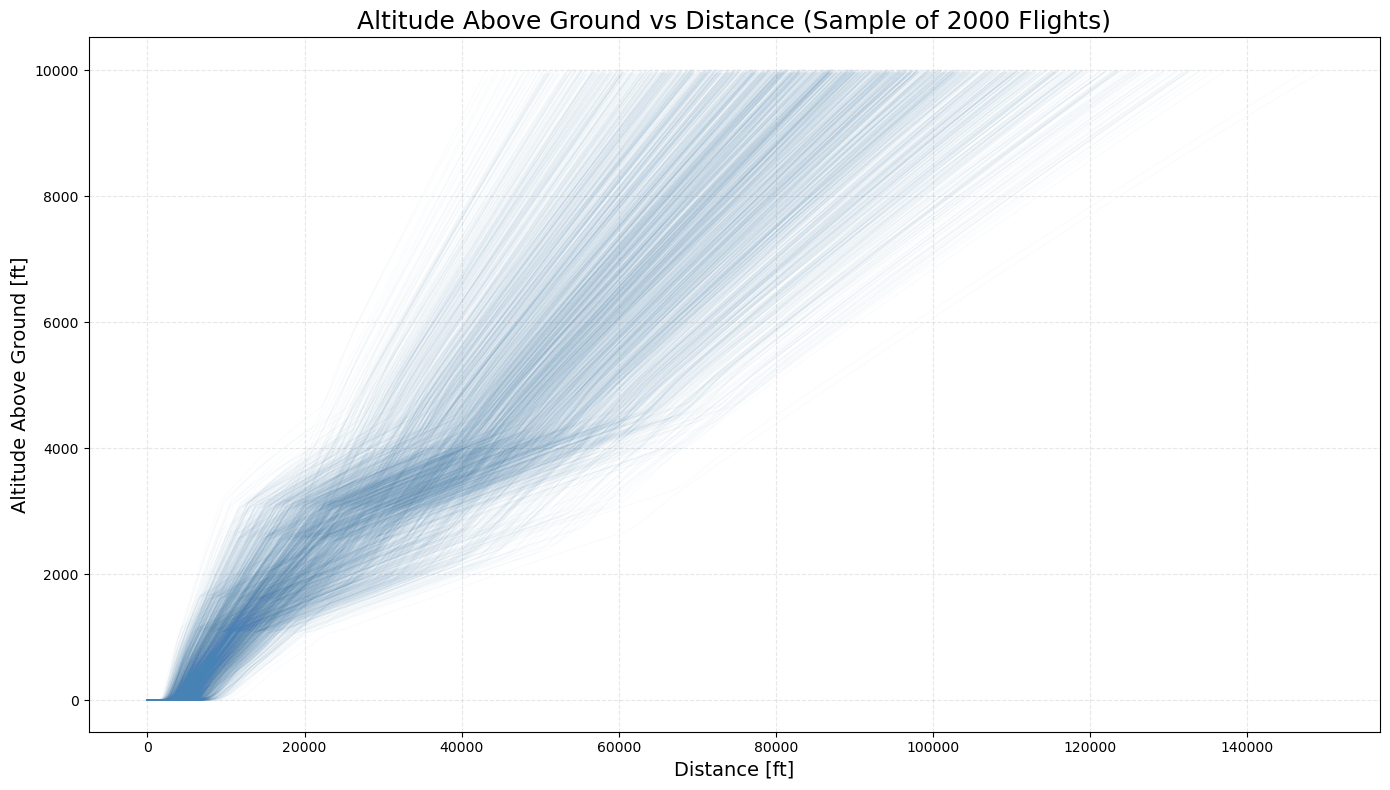

In [12]:
plt.figure(figsize=(14, 8))

for f in f_lst[:2000]:
    df = pd.read_csv(f)
    plt.plot(
        df["Distance"],
        df["Altitude_Above_Ground"],
        color="steelblue",
        linewidth=0.8,
        alpha=0.03
    )

plt.title("Altitude Above Ground vs Distance (Sample of 2000 Flights)", fontsize=18)
plt.xlabel("Distance [ft]", fontsize=14)
plt.ylabel("Altitude Above Ground [ft]", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

# Save the figure (high resolution)
plt.savefig("altitude_distance_plot.png", dpi=300)

plt.show()

## Weight Model Data

In [13]:
desired_columns = ["Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1", "acc", "wind_speed_2", "wind_dir_cos_2", "wind_dir_sin_2", "theta_2", "sigma_2", "delta_2", "roll_2", "climb_angle_2", "Vg_3", "Vc_3", "wind_speed_3", "wind_dir_cos_3", "wind_dir_sin_3", "theta_3", "sigma_3", "delta_3", "roll_3", "climb_angle_3", "acc_max", "Total_Weight"]

In [14]:
weight_min = 110000
weight_max = 174000
cutoff_weight_top = 0.75
cutoff_weight_bot = 0.25
throttle_top_max = 1.0
throttle_bot_max = 0.97
throttle_top_min = 0.935
throttle_bot_min = 0.89
counter = 0
null_counter = 0
i = 0
Data_Weight = pd.DataFrame(columns = desired_columns + ["ID"])
f_lst_bad = []
weight_lst = []
throttle_lst = []
for f in f_lst[:]:
    if np.mod(counter, 100)==0:
        print("counter = ", counter)
    counter+=1
    df = pd.read_csv(f)

    # Get the good slice of data for weight model
    t0 = df[df["Segment"]=="Take_Off"].iloc[-1]["Throttle"]
    weight_0 = df.iloc[0]["Total_Weight"]
    weight_ratio = (weight_0-weight_min)/(weight_max-weight_min)
    if weight_ratio>cutoff_weight_top:
        throttle_top = copy.copy(throttle_top_max)
    else:
        throttle_top = throttle_top_min + (throttle_top_max-throttle_top_min)/cutoff_weight_top*weight_ratio
    
    if weight_ratio<cutoff_weight_bot:
        throttle_bot = copy.copy(throttle_bot_min)
    else:
        throttle_bot = throttle_bot_min + (throttle_bot_max-throttle_bot_min)/(1-cutoff_weight_bot)*(weight_ratio-cutoff_weight_bot)

    if (t0<throttle_bot) or (t0>throttle_top):
        null_counter += 1
        f_lst_bad.append(f)
        continue
    data_temp = df[(df["Throttle"]==t0)&(df["Segment"]=="Slow_Climb")]
    tolerance = 3
    stability_window = 5
    stability_threshold = 3
    data_temp["near_command"] = (data_temp["CAS"].rolling(stability_window, center=True, min_periods=1).mean().sub(df.iloc[0]["Climb_CAS"]).abs() < tolerance)
    data_temp["cas_std"] = data_temp["CAS"].rolling(stability_window, center=True, min_periods=1).std()
    data_temp["stable"] = data_temp["cas_std"] < stability_threshold
    data_temp["good"] = data_temp["near_command"] & data_temp["stable"]
    data_temp["slice"] = (data_temp["good"] != data_temp["good"].shift()).cumsum()
    slices = data_temp[data_temp["good"]].groupby("slice")
    if np.sum(data_temp["good"])==0:
        null_counter+=1
        f_lst_bad.append(f)
        continue
    longest_slice_id = slices.size().idxmax()
    longest_slice = data_temp[data_temp["slice"] == longest_slice_id].copy()
    if len(longest_slice)==0:
        null_counter+=1
        f_lst_bad.append(f)
        continue
    else:
        weight_lst.append(weight_0)
        throttle_lst.append(t0)
        Data_Weight.loc[i, ["Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1"]] = longest_slice[["Ground_Speed", "CAS", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "vpath"]].mean().values
        # Data_Weight.loc[i, ["Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1"]] = df[(df["Altitude_Above_Ground"]>600) & (df["Altitude_Above_Ground"]<800)][["Ground_Speed", "CAS", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "vpath"]].mean().values
        Data_Weight.loc[i, ["Vg_3", "Vc_3", "wind_speed_3", "wind_dir_cos_3", "wind_dir_sin_3", "theta_3", "sigma_3", "delta_3", "roll_3", "climb_angle_3"]] = df[(df["Altitude_Above_Ground"]>9000) & (df["Altitude_Above_Ground"]<10100)][["Ground_Speed", "CAS", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "vpath"]].mean().values
        Data_Weight.loc[i, ["acc", "wind_speed_2", "wind_dir_cos_2", "wind_dir_sin_2", "theta_2", "sigma_2", "delta_2", "roll_2", "climb_angle_2"]] = df[df["Segment"]=="Acceleration"].iloc[-10:][["Acceleration", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "vpath"]].mean().values
        Data_Weight.loc[i, "Total_Weight"] = df["Total_Weight"].mean()
        Data_Weight.loc[i, "Climb_CAS"] = df.loc[0, "Climb_CAS"]
        Data_Weight.loc[i, "ID"] = f
        Data_Weight.loc[i, "Thrust_Max"] = np.max(df["Thrust"])
        df_acc = df[(df["Ground_Speed"]>5) & (df["Ground_Speed"]<15)]
        Data_Weight.loc[i, "acc_max"] = (df_acc.iloc[-1]["Ground_Speed"]-df_acc.iloc[0]["Ground_Speed"])/(df_acc.iloc[-1]["Time"]-df_acc.iloc[0]["Time"])
        i+=1

counter =  0
counter =  100
counter =  200
counter =  300
counter =  400
counter =  500
counter =  600
counter =  700
counter =  800
counter =  900
counter =  1000
counter =  1100
counter =  1200
counter =  1300
counter =  1400
counter =  1500
counter =  1600
counter =  1700
counter =  1800
counter =  1900
counter =  2000
counter =  2100
counter =  2200
counter =  2300
counter =  2400
counter =  2500
counter =  2600
counter =  2700
counter =  2800
counter =  2900
counter =  3000
counter =  3100
counter =  3200
counter =  3300
counter =  3400
counter =  3500
counter =  3600
counter =  3700
counter =  3800
counter =  3900
counter =  4000
counter =  4100
counter =  4200
counter =  4300
counter =  4400
counter =  4500
counter =  4600
counter =  4700
counter =  4800
counter =  4900
counter =  5000
counter =  5100
counter =  5200
counter =  5300
counter =  5400
counter =  5500
counter =  5600
counter =  5700
counter =  5800
counter =  5900
counter =  6000
counter =  6100
counter =  6200
coun

In [15]:
null_counter

5667

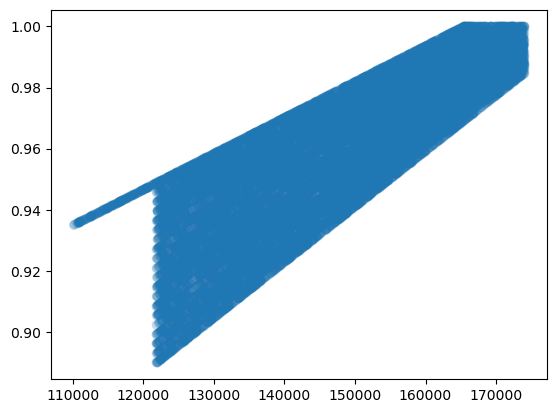

In [16]:
plt.scatter(weight_lst, throttle_lst, alpha=0.1)
plt.show()

In [17]:
Data_Weight = Data_Weight[Data_Weight["Total_Weight"]>123000]

In [18]:
n1 = 0.8
n2 = 0.9
Data_Weight.dropna(inplace=True)
train, val, test = np.split(Data_Weight.sample(frac=1, random_state=42), [int(n1*len(Data_Weight)), int(n2*len(Data_Weight))])

In [19]:
train

array([[np.float64(172.59819135321308), np.float64(172.19165105405062),
        np.float64(7.346264215503775), ...,
        'Data\\Departures\\2024-07-18---20-16-51.csv',
        172.02949658409236, 22488.031993943423],
       [np.float64(150.23499004854705), np.float64(168.04741789165297),
        np.float64(29.22954769591382), ...,
        'Data\\Departures\\2024-07-27---17-21-19.csv',
        168.53475086119255, 20689.67636625471],
       [np.float64(159.7420445336437), np.float64(159.92317581176758),
        np.float64(19.15289661923647), ...,
        'Data\\Departures\\2024-07-27---06-15-21.csv', 158.5139833104306,
        16885.8493341272],
       ...,
       [np.float64(142.8357494627144), np.float64(159.21503226987778),
        np.float64(27.578242498140877), ...,
        'Data\\Departures\\2024-07-16---13-43-14.csv', 158.1562600047604,
        19397.12329734232],
       [np.float64(161.07236729969785), np.float64(157.90763201032365),
        np.float64(4.388259214734077), ...,

In [20]:
train = pd.DataFrame(train, columns = Data_Weight.columns) 
val = pd.DataFrame(val, columns = Data_Weight.columns)
test = pd.DataFrame(test, columns = Data_Weight.columns)

In [21]:
test

,Vg_1,Vc_1,wind_speed_1,wind_dir_cos_1,wind_dir_sin_1,theta_1,sigma_1,delta_1,roll_1,climb_angle_1,...,theta_3,sigma_3,delta_3,roll_3,climb_angle_3,acc_max,Total_Weight,ID,Climb_CAS,Thrust_Max
0,158.374865,169.616113,10.86344,0.99533,0.066321,0.936929,1.012192,0.981059,-5.235552,10.297634,...,0.881883,0.7693,0.701831,-0.00027,7.330027,5.182957,162202.757819,Data\Departures\2024-07-28---18-45-50.csv,169.95074,25327.02295
1,136.908853,153.830988,17.043633,0.982666,-0.130336,0.944154,1.01905,0.995319,12.033464,14.115241,...,0.887821,0.774996,0.711789,0.000005,9.171222,4.857361,126134.01337,Data\Departures\2024-07-26---08-27-12.csv,153.155438,20759.240684
2,163.91462,161.804324,12.644105,0.965307,-0.17274,0.946238,0.847583,0.829673,10.293367,7.165854,...,0.889398,0.64414,0.592655,-0.00027,5.383932,4.390213,139552.401932,Data\Departures\2024-07-13---06-12-00.csv,160.615154,17939.430497
3,158.31582,166.142201,15.947592,0.997431,0.055067,0.990089,0.915337,0.937539,-1.90197,9.26201,...,0.927498,0.70561,0.677026,-0.000004,6.795367,4.308073,158505.345482,Data\Departures\2024-07-18---23-35-34.csv,166.067309,22461.892685
4,137.63154,152.003075,26.689808,0.998272,0.042644,0.965505,0.864295,0.86325,-4.401431,9.441092,...,0.905679,0.659505,0.617902,-0.008226,6.762543,4.53237,126996.746737,Data\Departures\2024-07-28---07-21-59.csv,152.90057,17878.761939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,137.873257,160.219517,28.347199,0.999123,-0.028113,0.962168,0.939993,0.935616,2.667014,11.288081,...,0.902301,0.714621,0.667042,-0.000275,7.913601,4.635557,146123.068019,Data\Departures\2024-07-27---05-22-43.csv,161.615589,22037.43935
2504,166.948335,172.593192,12.325812,0.985236,0.170514,1.00656,0.936353,0.974989,-5.411981,9.635231,...,0.938023,0.711691,0.690609,-0.001023,6.229562,4.621695,168278.551332,Data\Departures\2024-07-13---16-20-19.csv,172.186931,23392.575365
2505,165.669084,162.150546,7.508218,0.997133,0.044645,0.956889,0.880348,0.871442,-4.984878,7.563932,...,0.897776,0.668299,0.620675,0.00049,5.555831,4.253767,142255.041687,Data\Departures\2024-07-11---11-44-01.csv,163.453953,18784.880729
2506,124.079934,151.167827,28.325548,0.997408,-0.047946,0.953442,0.998642,0.984975,6.335383,15.080409,...,0.895164,0.758784,0.702662,0.00031,9.976132,5.355523,128004.876037,Data\Departures\2024-07-23---11-44-03.csv,153.416497,22178.266346


In [22]:
pd.concat([train, val]).to_csv("Data/Data_Train_Weight_Dep.csv", index=False)
test.to_csv("Data/Data_Test_Weight_Dep.csv", index=False)

In [23]:
Data_Weight.shape

(25073, 34)

# Read Training Data

In [24]:
Data = pd.read_csv("Data/Data_Train_Weight_Dep.csv")

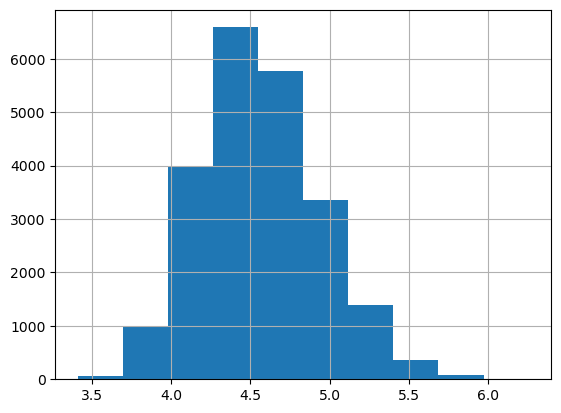

In [25]:
Data["acc_max"].hist()
plt.show()

In [26]:
Data[desired_columns].corr()["Total_Weight"].sort_values()

climb_angle_1    -0.433369
climb_angle_3    -0.327946
acc_max          -0.275748
acc              -0.275228
climb_angle_2    -0.139503
theta_3          -0.058584
theta_1          -0.056205
theta_2          -0.049610
wind_dir_sin_3   -0.012893
wind_dir_sin_2   -0.010193
wind_speed_2     -0.008704
wind_dir_cos_1   -0.007791
wind_speed_1     -0.006966
wind_speed_3     -0.006928
Vg_3             -0.005271
roll_1           -0.001415
roll_3            0.005069
wind_dir_sin_1    0.007847
wind_dir_cos_3    0.032680
wind_dir_cos_2    0.032877
roll_2            0.046955
delta_3           0.118981
delta_2           0.125501
delta_1           0.126547
sigma_3           0.136021
sigma_2           0.140358
sigma_1           0.141822
Vg_1              0.408637
Vc_3              0.929729
Vc_1              0.973567
Total_Weight      1.000000
Name: Total_Weight, dtype: float64

In [27]:
# all_names = desired_columns
all_names = ["Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1", "Total_Weight"]
x_names = all_names[:-1]

In [28]:
# scaler = StandardScaler().fit(Data[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].values)
# Data_scaled = pd.DataFrame(scaler.transform(Data[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].values), index=Data.index, columns=Data[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].columns)
scaler = StandardScaler().fit(Data[all_names].values)
Data_scaled = pd.DataFrame(scaler.transform(Data[all_names].values), index=Data.index, columns=all_names)

In [29]:
n1 = 0.8
n2 = 0.9
# X_train, X_val, y_train, y_val = train_test_split(Data_scaled[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3"]], Data_scaled[['Total_Weight']], test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(Data_scaled[x_names], Data_scaled[['Total_Weight']], test_size=(n2-n1)/n2)

# Create the Weight Model

In [30]:
model = Sequential()
model_dropout = 0.0
model_activation = 'tanh'
batch_size = 16

model.add(Dense(16, input_dim=X_train.shape[1], activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(16, activation=model_activation))
model.add(Dropout(model_dropout))

model.add(Dense(1))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mae')

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465 (1.82 KB)

 Trainable params: 465 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Weight Model

## 1st LR

In [32]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=3)

In [33]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val),
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1854 - val_loss: 0.1817
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 883us/step - loss: 0.1725 - val_loss: 0.1675
Epoch 3/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 940us/step - loss: 0.1666 - val_loss: 0.1624
Epoch 4/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 790us/step - loss: 0.1670 - val_loss: 0.1658
Epoch 5/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 891us/step - loss: 0.1652 - val_loss: 0.1689
Epoch 6/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 918us/step - loss: 0.1658 - val_loss: 0.1669


In [34]:
losses = pd.DataFrame(model.history.history)

## 2nd LR

In [35]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [36]:
model.optimizer.learning_rate.assign(0.001)

<tf.Tensor: shape=(), dtype=float32, numpy=0.0010000000474974513>

In [37]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 921us/step - loss: 0.1536 - val_loss: 0.1547
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1519 - val_loss: 0.1537
Epoch 3/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 877us/step - loss: 0.1517 - val_loss: 0.1548
Epoch 4/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 762us/step - loss: 0.1519 - val_loss: 0.1538


In [38]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)

## 3rd LR

In [39]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=1)

In [40]:
model.optimizer.learning_rate.assign(0.0001)

<tf.Tensor: shape=(), dtype=float32, numpy=9.999999747378752e-05>

In [41]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 968us/step - loss: 0.1502 - val_loss: 0.1528
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 867us/step - loss: 0.1500 - val_loss: 0.1526


In [42]:
predictions = model.predict(X_val)
mae_current = mean_absolute_error(y_val, predictions)
print("mae = ", mae_current*18000/170000*100)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step
mae =  1.6160889934091007


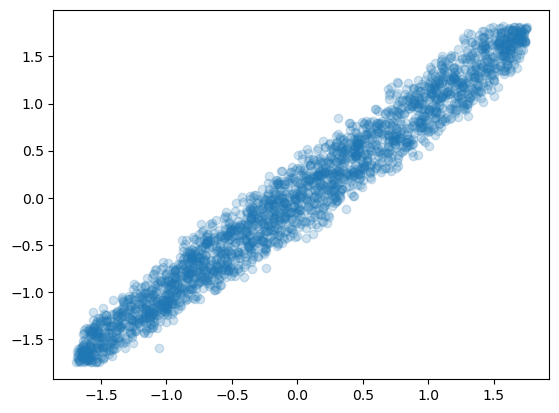

In [43]:
plt.scatter(predictions.flatten(), y_val, alpha=0.2)
plt.show()

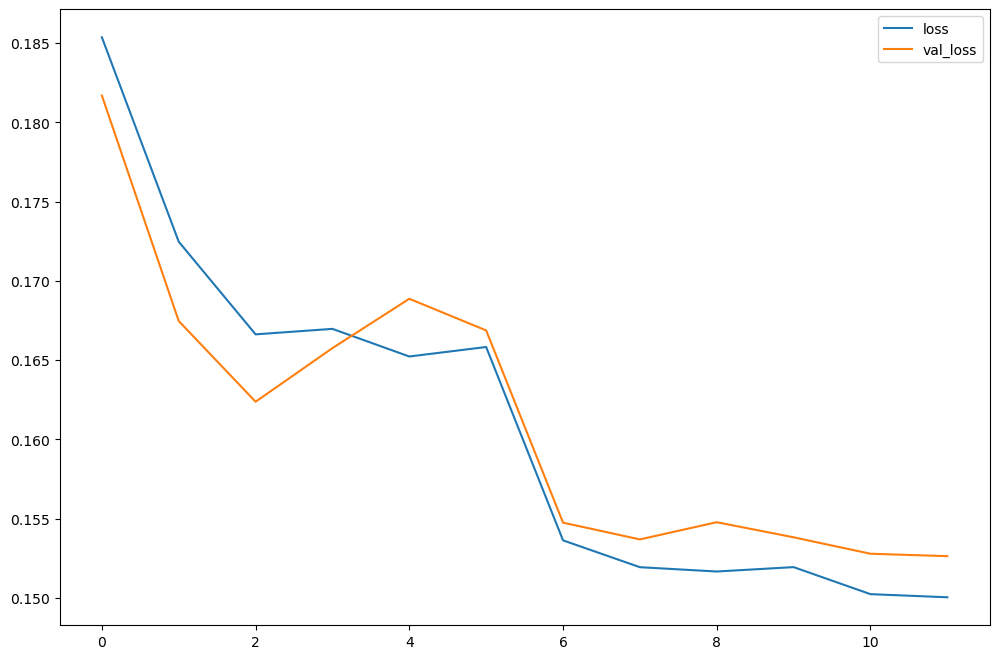

In [44]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)
losses.reset_index(drop=True).plot(figsize=(12,8))
plt.show()

# Test Score

In [45]:
Data_test = pd.read_csv("Data/Data_Test_Weight_Dep.csv")

In [46]:
# Data_test_scaled = pd.DataFrame(scaler.transform(Data_test[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].values), index=Data_test.index, columns=Data_test[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].columns)
Data_test_scaled = pd.DataFrame(scaler.transform(Data_test[all_names].values), index=Data_test.index, columns=all_names)

In [47]:
X_test_scaled = Data_test_scaled[x_names]
y_test_scaled = Data_test_scaled[["Total_Weight"]]

In [48]:
y_pred_scaled = model.predict(X_test_scaled)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step


In [49]:
mae_current = mean_absolute_error(y_test_scaled, y_pred_scaled)
print("mae = ", mae_current*18000/170000*100)

mae =  1.582196442519917


In [50]:
output = scaler.inverse_transform(np.concatenate((X_test_scaled, y_pred_scaled), axis=1))

In [51]:
print("r2 score for weight predictions: %.5f" % (metrics.r2_score(y_test_scaled, y_pred_scaled)))
print("MAE score for weight predictions: %.5f" % (metrics.mean_absolute_error(Data_test["Total_Weight"], output[:,-1])))
print("MAE score for weight predictions as percentage: %.5f %%" % np.mean(100*np.abs(Data_test["Total_Weight"]-output[:,-1])*Data_test["Total_Weight"]**-1))
print("Maximum error for weight predictions: %.5f" % np.max(np.abs(Data_test["Total_Weight"]-output[:,-1])))

r2 score for weight predictions: 0.96795
MAE score for weight predictions: 2103.00600
MAE score for weight predictions as percentage: 1.42364 %
Maximum error for weight predictions: 7922.16420


In [52]:
output = scaler.inverse_transform(np.concatenate((X_test_scaled, y_pred_scaled), axis=1))
output

array([[ 1.58374865e+02,  1.69616113e+02,  1.08634401e+01, ...,
        -5.23555224e+00,  1.02976343e+01,  1.63207087e+05],
       [ 1.36908853e+02,  1.53830988e+02,  1.70436326e+01, ...,
         1.20334643e+01,  1.41152415e+01,  1.25895857e+05],
       [ 1.63914620e+02,  1.61804324e+02,  1.26441050e+01, ...,
         1.02933667e+01,  7.16585439e+00,  1.43087878e+05],
       ...,
       [ 1.65669084e+02,  1.62150546e+02,  7.50821820e+00, ...,
        -4.98487817e+00,  7.56393224e+00,  1.44553298e+05],
       [ 1.24079934e+02,  1.51167827e+02,  2.83255485e+01, ...,
         6.33538282e+00,  1.50804094e+01,  1.24284653e+05],
       [ 1.39142721e+02,  1.58862057e+02,  2.92096939e+01, ...,
         2.86764750e+00,  9.87938225e+00,  1.37357660e+05]])

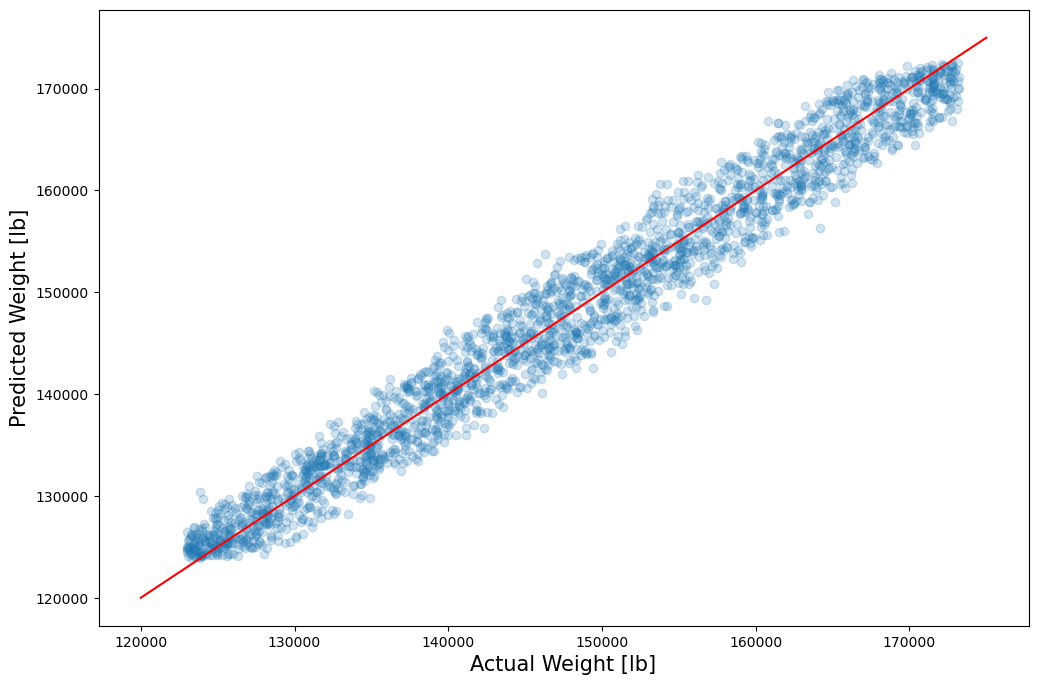

In [53]:
plt.figure(figsize=(12,8))
plt.scatter(Data_test[["Total_Weight"]], output[:,-1], alpha=0.2)
plt.ylabel("Predicted Weight [lb]", fontsize=15)
plt.xlabel("Actual Weight [lb]", fontsize=15)
plt.plot([120000, 175000], [120000, 175000], "r")
# plt.xlim([430000*0.453592, 690000*0.453592])
# plt.ylim([0, 210000])
# plt.xticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
# plt.yticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
# plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Weight_0.png", bbox_inches="tight", facecolor='white', transparent=False)

# Save the figure (high resolution)
plt.savefig("weight_predictions_scatter.png", dpi=300)
plt.show()

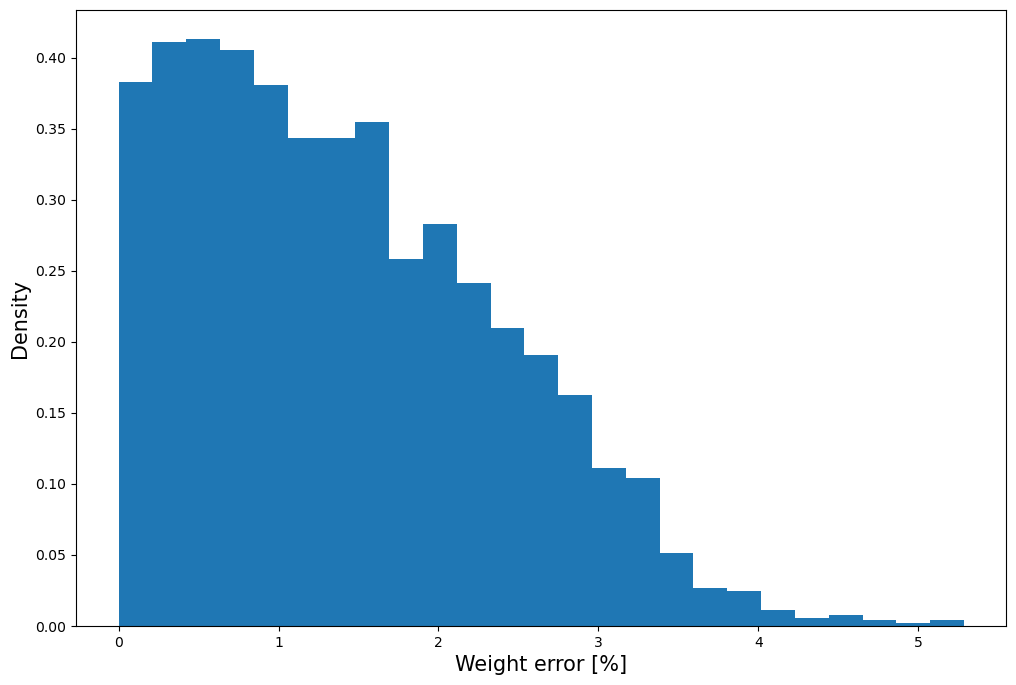

In [54]:
errors_lst = np.abs(100*(output[:,-1] - Data_test["Total_Weight"].values)/Data_test["Total_Weight"])
plt.figure(figsize=(12,8))
plt.hist(errors_lst, bins=25, ec="k", density=True)
plt.xlabel("Weight error [%]", fontsize=15)
plt.ylabel("Density", fontsize=15)
# plt.xlim([-5,5])
# plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Weight_1.png", bbox_inches="tight", facecolor='white', transparent=False)

# Save the figure (high resolution)
plt.savefig("weight_predictions_error_distribution.png", dpi=300)
plt.show()

# Save Model

In [55]:
model.save("Models\model_weight\model_weight.keras")
dump(scaler, "Models\model_weight\scaler_weight.bin", compress=True)

['Models\\model_weight\\scaler_weight.bin']

# Thrust Model Data Gathering

In [56]:
thrust_columns = ["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Total_Weight", "Thrust"]

In [57]:
Data_test = pd.read_csv("Data/Data_Test_Weight_Dep.csv")
f_lst_test = list(Data_test["ID"])

In [58]:
len(f_lst_test)

2508

In [59]:
n = 0.9
f_lst_train = [f for f in f_lst if f not in f_lst_test]
random.shuffle(f_lst_train)  # shuffle in-place
train_end = int(n * len(f_lst_train))
train = f_lst_train[:train_end]
val = f_lst_train[train_end:]
test = f_lst_test

In [60]:
Data_Train_thrust = pd.DataFrame(columns=thrust_columns)
Data_Val_thrust = pd.DataFrame(columns=thrust_columns)
Data_Test_Thrust = pd.DataFrame(columns=thrust_columns)

In [61]:
dfs = []
for f in train[:]:
    df = pd.read_csv(f)
    dfs.append(df[thrust_columns])
Data_Train_Thrust = pd.concat(dfs, ignore_index=True)
Data_Train_Thrust.to_csv("Data/Data_Train_Thrust_Dep.csv", index=False)

dfs = []
for f in val[:]:
    df = pd.read_csv(f)
    dfs.append(df[thrust_columns])
Data_Val_Thrust = pd.concat(dfs, ignore_index=True)
Data_Val_Thrust.to_csv("Data/Data_Val_Thrust_Dep.csv", index=False)

dfs = []
for f in test[:]:
    df = pd.read_csv(f)
    dfs.append(df[thrust_columns])
Data_Test_Thrust = pd.concat(dfs, ignore_index=True)
Data_Test_Thrust.to_csv("Data/Data_Test_Thrust_Dep.csv", index=False)


KeyboardInterrupt: 

# Read the Data for Thrust Model

In [ ]:
Data_train = pd.read_csv("Data\Data_Train_Thrust_Dep.csv")
Data_val = pd.read_csv("Data\Data_Val_Thrust_Dep.csv")
Data_test = pd.read_csv("Data\Data_Test_Thrust_Dep.csv")

In [ ]:
scaler = StandardScaler().fit(Data_train.values)

In [ ]:
Data_train_scaled = pd.DataFrame(scaler.transform(Data_train.values), index=Data_train.index, columns=Data_train.columns)
Data_train_scaled.dropna(inplace=True)

In [ ]:
Data_val_scaled = pd.DataFrame(scaler.transform(Data_val.values), index=Data_val.index, columns=Data_val.columns)
Data_val_scaled.dropna(inplace=True)

In [ ]:
X_train = Data_train_scaled[thrust_columns[:-1]]
y_train = Data_train_scaled[['Thrust']]
X_val = Data_val_scaled[thrust_columns[:-1]]
y_val = Data_val_scaled[['Thrust']]

In [1]:
X_train.shape

NameError: name 'X_train' is not defined

# Create the Thrust Model

In [114]:
model = Sequential()
model_dropout = 0.02
model_activation = 'sigmoid'
batch_size = 256

model.add(Dense(64, input_dim=X_train.shape[1], activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(64, activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(32, activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(16, activation=model_activation))
model.add(Dropout(model_dropout))

model.add(Dense(1))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mae')

In [115]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,617 (29.75 KB)

 Trainable params: 7,617 (29.75 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Thrust Model

## 1st LR

In [116]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=3)

In [117]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val),
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - loss: 0.1297 - val_loss: 0.1029
Epoch 2/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 34s 1ms/step - loss: 0.1115 - val_loss: 0.1107
Epoch 3/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.1068 - val_loss: 0.0977
Epoch 4/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 34s 1ms/step - loss: 0.1044 - val_loss: 0.0892
Epoch 5/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - loss: 0.1029 - val_loss: 0.0908
Epoch 6/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.1018 - val_loss: 0.0920
Epoch 7/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 33s 1ms/step - loss: 0.1007 - val_loss: 0.0937


In [122]:
losses = pd.DataFrame(model.history.history)


## 2nd LR

In [123]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [124]:
model.optimizer.learning_rate.assign(0.001)

<tf.Tensor: shape=(), dtype=float32, numpy=0.0010000000474974513>

In [125]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0946 - val_loss: 0.0848
Epoch 2/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0942 - val_loss: 0.0838
Epoch 3/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0940 - val_loss: 0.0849
Epoch 4/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0939 - val_loss: 0.0831
Epoch 5/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0937 - val_loss: 0.0833
Epoch 6/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0936 - val_loss: 0.0825
Epoch 7/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0934 - val_loss: 0.0837
Epoch 8/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0934 - val_loss: 0.0841


In [126]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)

## 3rd LR

In [127]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [128]:
model.optimizer.learning_rate.assign(0.0001)

<tf.Tensor: shape=(), dtype=float32, numpy=9.999999747378752e-05>

In [129]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0927 - val_loss: 0.0831
Epoch 2/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0926 - val_loss: 0.0828
Epoch 3/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - loss: 0.0927 - val_loss: 0.0831


In [132]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)
losses.reset_index(drop=True).plot(figsize=(12,8))


<Axes: >

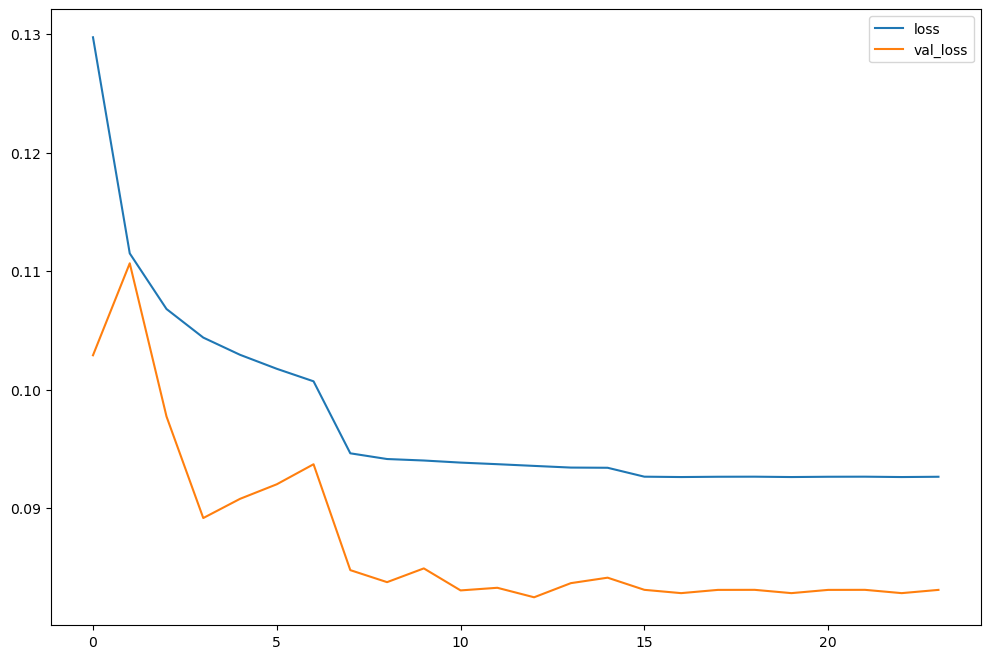

In [133]:
plt.show()

# Test Score

In [134]:
Data_test_scaled = pd.DataFrame(scaler.transform(Data_test.values), index=Data_test.index, columns=Data_test.columns)
Data_test_scaled.dropna(inplace=True)

In [135]:
X_test_scaled = Data_test_scaled[thrust_columns[:-1]]
y_test_scaled = Data_test_scaled[['Thrust']]

In [136]:
y_pred_scaled = model.predict(X_test_scaled)

19152/19152 ━━━━━━━━━━━━━━━━━━━━ 9s 468us/step


In [137]:
print("r2 score for thrust predictions: %.5f" % (metrics.r2_score(y_test_scaled, y_pred_scaled)))
print("MAE score for thrust predictions: %.5f" % (metrics.mean_absolute_error(y_test_scaled, y_pred_scaled)))
print("Maximum error for thrust predictions: %.5f" % np.max(y_pred_scaled-y_test_scaled))

r2 score for thrust predictions: 0.98366
MAE score for thrust predictions: 0.07647
Maximum error for thrust predictions: 4.50957


# Save Model

In [138]:
model.save("Models\model_thrust\model_thrust.keras")
dump(scaler, "Models\model_thrust\scaler_thrust.bin", compress=True)

['Models\\model_thrust\\scaler_thrust.bin']

# Predict Outputs for a Single Flight

In [231]:
model_thrust = keras.models.load_model(r"Models\model_thrust\model_thrust.keras")
scaler_thrust = load(r"Models\model_thrust\scaler_thrust.bin")

In [232]:
test_flight = pd.read_csv(test[200])

NameError: name 'test' is not defined

In [141]:
flight_data = test_flight[thrust_columns]
flight_data_scaled = pd.DataFrame(scaler_thrust.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
X_flight = flight_data_scaled[thrust_columns[:-1]]

start_time = time.time()
y_pred_scaled = model_thrust.predict(X_flight)
# y_pred_scaled = model_thrust(X_flight)
# y_pred_tensor = y_pred_scaled['dense_9']
# y_pred_np = y_pred_tensor.numpy().reshape(-1, 1)
output = scaler_thrust.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
# output = scaler_thrust.inverse_transform(np.concatenate((X_flight.values, y_pred_np), axis=1))
#output = scaler.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
y_pred = output[:,-1]
end_time = time.time()
print(end_time - start_time)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
0.13520073890686035


In [142]:
print("r2 score for thrust predictions with exact weight: %.5f" % (metrics.r2_score(flight_data["Thrust"], y_pred)))
print("MAE score for thrust predictions with exact weight: %.5f" % (metrics.mean_absolute_error(flight_data["Thrust"], y_pred)))
print("Maximum error for thrust predictions with exact weight: %.5f" % np.max(y_pred-flight_data["Thrust"]))

r2 score for thrust predictions with exact weight: 0.96281
MAE score for thrust predictions with exact weight: 316.88785
Maximum error for thrust predictions with exact weight: 1237.29997


In [210]:
y_pred

array([ 4962.02825027, 14335.41739121, 22237.6559622 , 24343.70888566,
       24483.72959296, 24360.26291116, 24179.75216771, 24062.6099317 ,
       23937.09816558, 23783.91088524, 23541.5285446 , 23432.44744747,
       23243.54291842, 23015.14698639, 22880.38001825, 22746.49179187,
       22588.65646661, 22401.89127178, 22263.77496697, 22146.80529145,
       22046.52893723, 21917.39270787, 21821.55649438, 21706.32281894,
       21580.21367474, 21469.89346859, 21210.8406761 , 21180.06738928,
       21290.72925135, 21270.68590034, 20665.75120487, 21223.80419604,
       21353.81293003, 21139.8878234 , 21313.05816253, 20759.67677876,
       21095.27851202, 21057.87585325, 20921.46921398, 20821.20672005,
       20762.33933856, 20727.39757252, 20664.28340121, 20663.64790737,
       20730.06082533, 20783.32103052, 20779.42351977, 19636.73421328,
       19383.49615479, 19338.38406174, 19300.40966642, 19181.8911046 ,
       19096.11502889, 18990.6185467 , 18913.87972009, 18871.72298526,
      

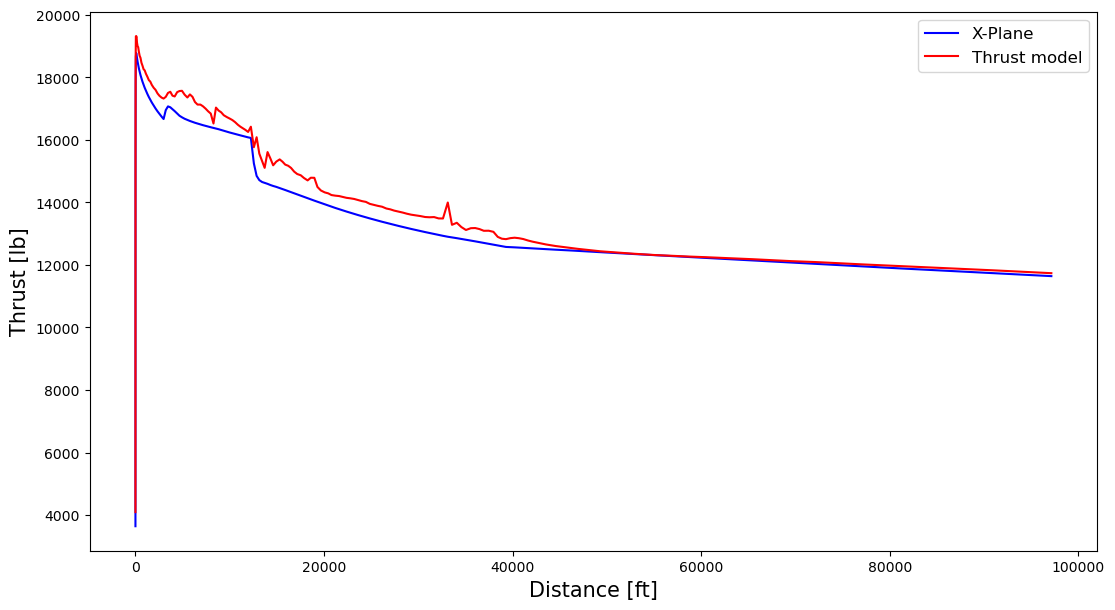

In [143]:
plt.figure(figsize=(13,7))
plt.plot(test_flight["Distance"], test_flight["Thrust"], "b")
plt.plot(test_flight["Distance"], y_pred, "r")
plt.xlabel("Distance [ft]", fontsize=15)
plt.ylabel("Thrust [lb]", fontsize=15)
plt.legend(["X-Plane", "Thrust model"], fontsize=12)
# plt.xticks(ticks=[0,20000,40000,60000,80000,100000,120000,140000], labels=["0","20,000","40,000",""])
# plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Thrust_0.png", bbox_inches="tight", facecolor='white', transparent=False)

plt.savefig("thrust_predictions_single_flight.png", dpi=300)
plt.show()

## Normal Thrust Model Error on Max Thrust Values

In [144]:
df_results = pd.DataFrame(columns = ["R2", "MAE", "Thrust_Max_Pred", "Thrust_Max_Actual", "Thrust_Maxx_Error_Perc"])
i = 0
for f in test:
    test_flight = pd.read_csv(f)
    flight_data = test_flight[thrust_columns]
    flight_data.dropna(inplace=True)
    flight_data_scaled = pd.DataFrame(scaler_thrust.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
    X_flight = flight_data_scaled[thrust_columns[:-1]]
    
    y_pred_scaled = model_thrust.predict(X_flight)
    output = scaler_thrust.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
    y_pred = output[:,-1]

    df_results.loc[i, "R2"] = metrics.r2_score(flight_data["Thrust"], y_pred)
    df_results.loc[i, "MAE"] = metrics.mean_absolute_error(flight_data["Thrust"], y_pred)
    df_results.loc[i, "Thrust_Max_Pred"] = np.max(y_pred)
    df_results.loc[i, "Thrust_Max_Actual"] = np.max(flight_data["Thrust"])
    df_results.loc[i, "Thrust_Max_Error_Perc"] = 100*np.abs(df_results.loc[i, "Thrust_Max_Pred"]-df_results.loc[i, "Thrust_Max_Actual"])/df_results.loc[i, "Thrust_Max_Actual"]
    i += 1

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━

In [145]:
print("r2 score for thrust max predictions: %.5f" % (metrics.r2_score(df_results["Thrust_Max_Actual"], df_results["Thrust_Max_Pred"])))
print("MAE score for thrust max predictions: %.5f" % (metrics.mean_absolute_error(df_results["Thrust_Max_Actual"], df_results["Thrust_Max_Pred"])))
print("MAE score for thrust max predictions as percentage: %.5f %%" % np.mean(df_results["Thrust_Max_Error_Perc"]))
print("Maximum error for thrust max predictions: %.5f" % np.max(np.abs(df_results["Thrust_Max_Actual"]-df_results["Thrust_Max_Pred"])))

r2 score for thrust max predictions: 0.94084
MAE score for thrust max predictions: 378.18173
MAE score for thrust max predictions as percentage: 1.84462 %
Maximum error for thrust max predictions: 2664.69855


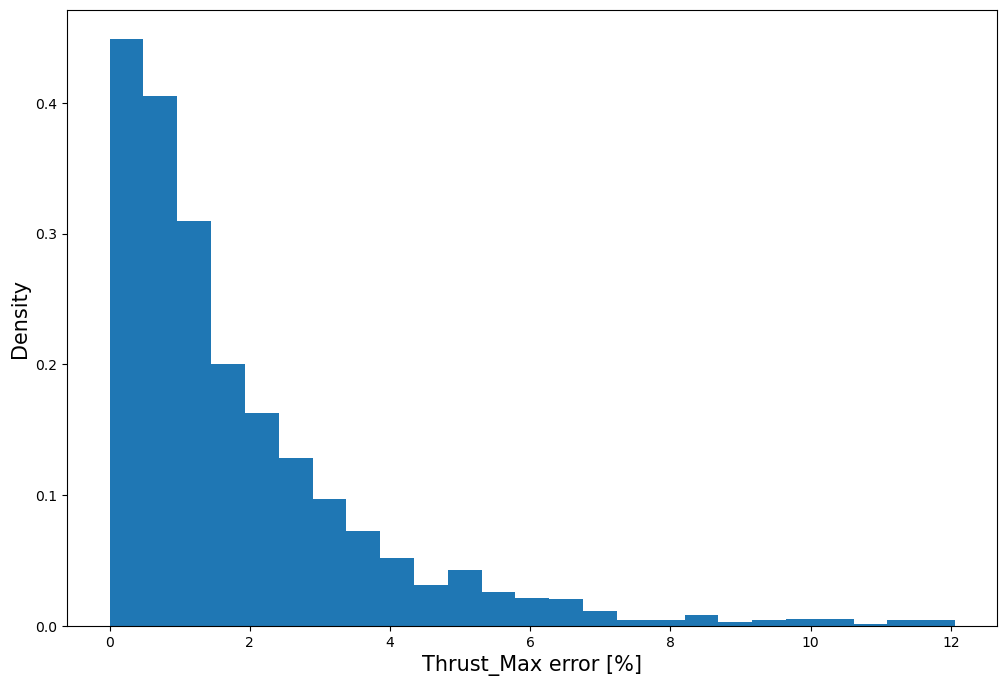

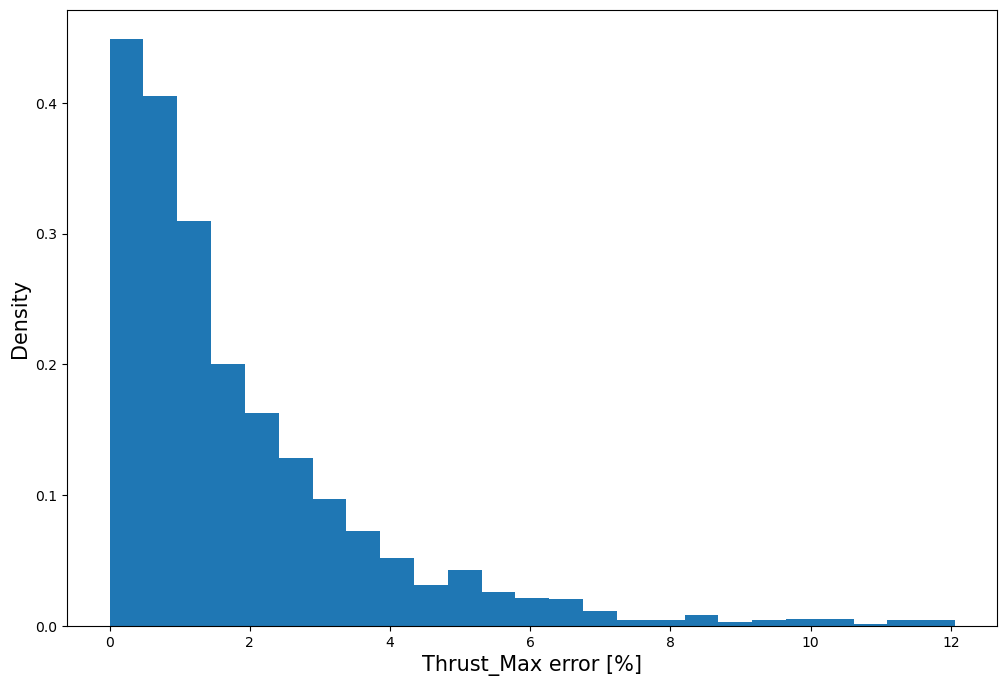

In [147]:
plt.figure(figsize=(12,8))
plt.hist(df_results["Thrust_Max_Error_Perc"], bins=25, ec="k", density=True)
plt.xlabel("Thrust_Max error [%]", fontsize=15)
plt.ylabel("Density", fontsize=15)
plt.show()

# Thrust Max Model

In [148]:
Data = pd.read_csv("Data/Data_Train_Weight_Dep.csv")
n1 = 0.8
n2 = 0.9

In [149]:
# all_names = desired_columns
all_names = ["acc_max", "Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1", "Total_Weight", "Thrust_Max"]
x_names = all_names[:-1]

In [150]:
scaler = StandardScaler().fit(Data[all_names].values)
Data_scaled = pd.DataFrame(scaler.transform(Data[all_names].values), index=Data.index, columns=all_names)

In [151]:
X_train, X_val, y_train, y_val = train_test_split(Data_scaled[x_names], Data_scaled[['Thrust_Max']], test_size=(n2-n1)/n2)

## Create the Model

In [152]:
model = Sequential()
model_dropout = 0.0
model_activation = 'tanh'
batch_size = 16

model.add(Dense(16, input_dim=X_train.shape[1], activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(16, activation=model_activation))
model.add(Dropout(model_dropout))

model.add(Dense(1))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mae')

In [153]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

## Train the thrust max Model

### 1st LR

In [154]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=3)

In [155]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val),
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 2s 854us/step - loss: 0.2276 - val_loss: 0.2396
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 709us/step - loss: 0.2054 - val_loss: 0.1987
Epoch 3/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 718us/step - loss: 0.2015 - val_loss: 0.2052
Epoch 4/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 786us/step - loss: 0.1973 - val_loss: 0.2049
Epoch 5/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 720us/step - loss: 0.1995 - val_loss: 0.2029


In [156]:
losses = pd.DataFrame(model.history.history)

### 2nd LR

In [157]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [158]:
model.optimizer.learning_rate.assign(0.001)

<tf.Tensor: shape=(), dtype=float32, numpy=0.0010000000474974513>

In [159]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 758us/step - loss: 0.1789 - val_loss: 0.1810
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 782us/step - loss: 0.1769 - val_loss: 0.1795
Epoch 3/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 822us/step - loss: 0.1761 - val_loss: 0.1798
Epoch 4/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 760us/step - loss: 0.1753 - val_loss: 0.1774
Epoch 5/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 706us/step - loss: 0.1747 - val_loss: 0.1765
Epoch 6/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - loss: 0.1745 - val_loss: 0.1767
Epoch 7/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step - loss: 0.1740 - val_loss: 0.1769


In [160]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)

### 3rd LR

In [161]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [162]:
model.optimizer.learning_rate.assign(0.0001)

<tf.Tensor: shape=(), dtype=float32, numpy=9.999999747378752e-05>

In [163]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step - loss: 0.1714 - val_loss: 0.1742
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.1712 - val_loss: 0.1743
Epoch 3/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step - loss: 0.1710 - val_loss: 0.1744


In [164]:
predictions = model.predict(X_val)
mae_current = mean_absolute_error(y_val, predictions)
print("mae = ", mae_current*18000/170000*100)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
mae =  1.8468189239501953


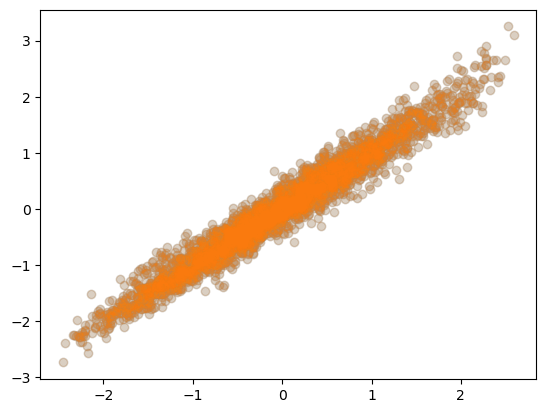

In [166]:
plt.scatter(predictions.flatten(), y_val, alpha=0.2)
plt.show()

In [170]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)
losses.reset_index(drop=True).plot(figsize=(12,8))


<Axes: >

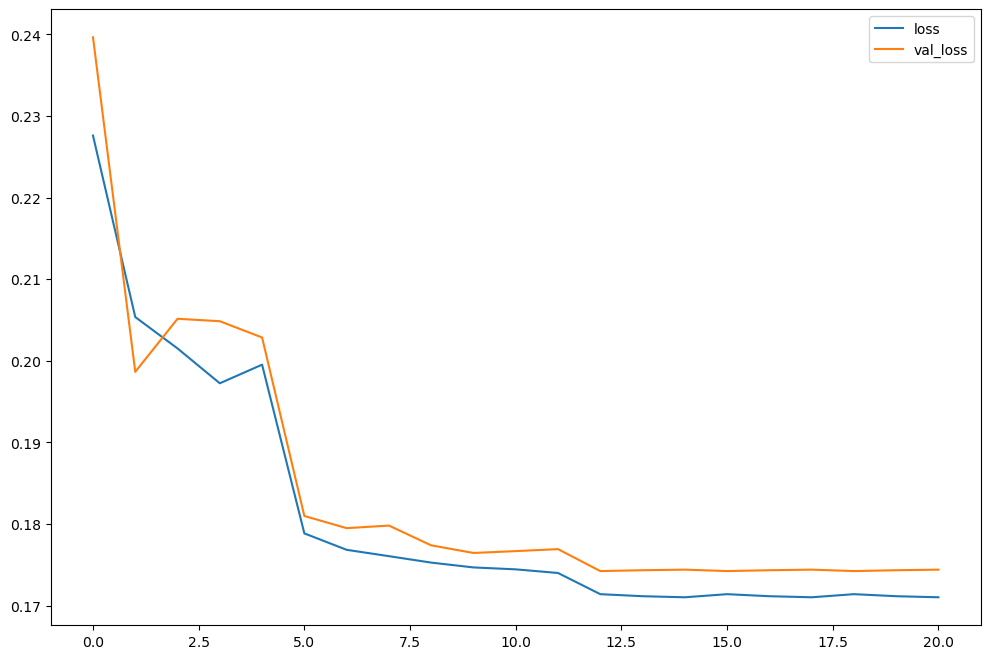

In [171]:
plt.show()

## Test Score

In [172]:
Data_test = pd.read_csv("Data/Data_Test_Weight_Dep.csv")

In [173]:
Data_test_scaled = pd.DataFrame(scaler.transform(Data_test[all_names].values), index=Data_test.index, columns=all_names)

In [174]:
X_test_scaled = Data_test_scaled[x_names]
y_test_scaled = Data_test_scaled[["Thrust_Max"]]

In [175]:
y_pred_scaled = model.predict(X_test_scaled)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step


In [176]:
output = scaler.inverse_transform(np.concatenate((X_test_scaled, y_pred_scaled), axis=1))

In [177]:
print("r2 score for thrust max predictions: %.5f" % (metrics.r2_score(y_test_scaled, y_pred_scaled)))
print("MAE score for thrust max predictions: %.5f" % (metrics.mean_absolute_error(Data_test["Thrust_Max"], output[:,-1])))
print("MAE score for thrust max predictions as percentage: %.5f %%" % np.mean(100*np.abs(Data_test["Thrust_Max"]-output[:,-1])*Data_test["Thrust_Max"]**-1))
print("Maximum error for thrust max predictions: %.5f" % np.max(np.abs(Data_test["Thrust_Max"]-output[:,-1])))

r2 score for thrust max predictions: 0.94981
MAE score for thrust max predictions: 382.26181
MAE score for thrust max predictions as percentage: 1.82117 %
Maximum error for thrust max predictions: 1835.02743


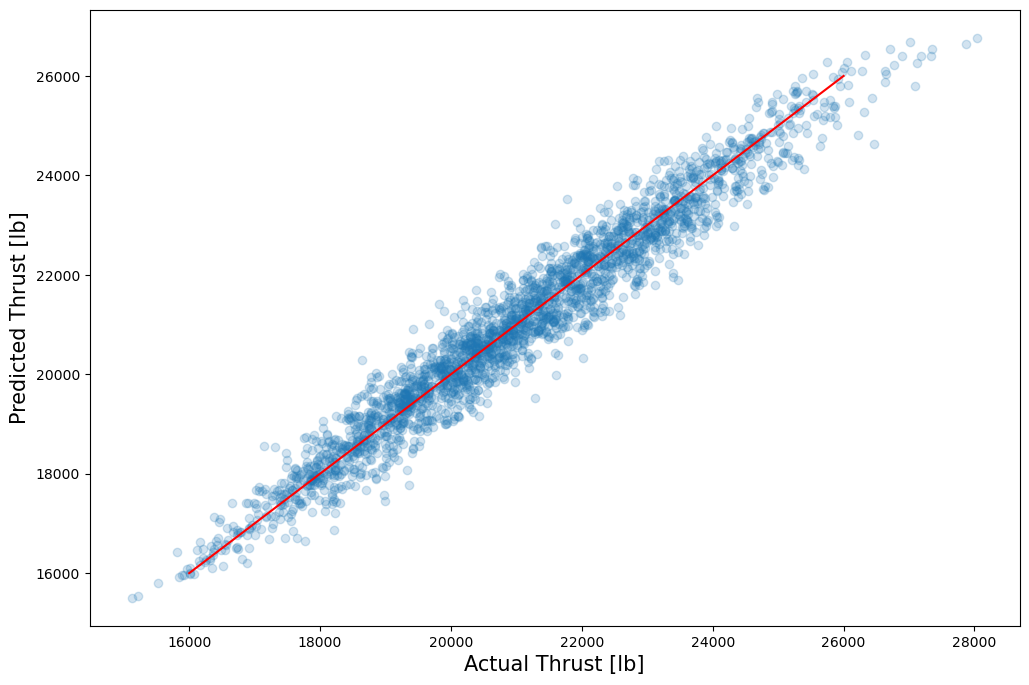

In [178]:
plt.figure(figsize=(12,8))
plt.scatter(Data_test[["Thrust_Max"]], output[:,-1], alpha=0.2)
plt.ylabel("Predicted Thrust [lb]", fontsize=15)
plt.xlabel("Actual Thrust [lb]", fontsize=15)
plt.plot([16000, 26000], [16000, 26000], "r")
# plt.xlim([430000*0.453592, 690000*0.453592])
# plt.ylim([0, 210000])
# plt.xticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
# plt.yticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
# plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Weight_0.png", bbox_inches="tight", facecolor='white', transparent=False)

# Save the figure (high resolution)
plt.savefig("thrust_max_predictions_scatter.png", dpi=300)
plt.show()

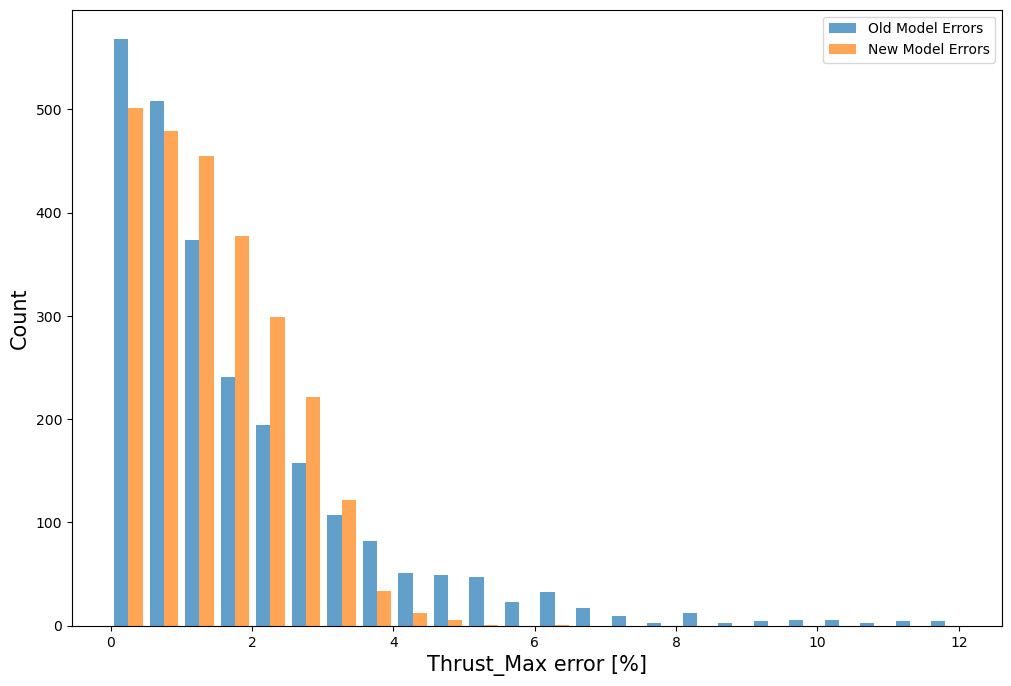

In [179]:
data1 = df_results["Thrust_Max_Error_Perc"]
data2 = errors_lst

# Compute bins
bins = np.linspace(min(data1.min(), data2.min()),
                   max(data1.max(), data2.max()), 25)

# Histogram counts
hist1, _ = np.histogram(data1, bins=bins)
hist2, _ = np.histogram(data2, bins=bins)

# Compute bin centers
bin_centers = 0.5 * (bins[1:] + bins[:-1])

width = (bins[1] - bins[0]) * 0.4

plt.figure(figsize=(12,8))
plt.bar(bin_centers - width/2, hist1, width=width, alpha=0.7, label="Old Model Errors")
plt.bar(bin_centers + width/2, hist2, width=width, alpha=0.7, label="New Model Errors")

plt.xlabel("Thrust_Max error [%]", fontsize=15)
plt.ylabel("Count", fontsize=15)
plt.legend()
plt.savefig("thrust_max_predictions_comparison.png", dpi=300)
plt.show()

### Save the Model

In [180]:
model.save("Models\model_thrust\model_thrust_max.keras")
dump(scaler, "Models\model_thrust\scaler_thrust_max.bin", compress=True)

['Models\\model_thrust\\scaler_thrust_max.bin']

# TCN Thrust Model

In [70]:
import os
import pandas as pd

Data_dir = "Data/Departures"
f_lst = []
for f in os.listdir(Data_dir):
    if f.endswith(".csv"):
        f_lst.append(os.path.join(Data_dir, f))

Data_test = pd.read_csv("Data/Data_Test_Weight_Dep.csv")
f_lst_test = list(Data_test["ID"])
f_lst_train = [f for f in f_lst if f not in f_lst_test]
len(f_lst_test)

2508

In [71]:
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# ------------------------
# Configuration / Hyperparams
# ------------------------
DATA_DIR = "Data/Departures"
BATCH_SIZE = 16
NUM_EPOCHS = 30
LR = 1e-3
HIDDEN_SIZE = 128
DROPOUT = 0.2
MIN_JUMP = 0
MAX_JUMP = 8
DEVICE = torch.device("cpu")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

POINT_FEATURES = [
    "Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta",
    "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos",
    "Wind_dir_sin", "Total_Weight"
]

# ------------------------
# Preprocessing 
# ------------------------
def sample_sequence_from_df(df: pd.DataFrame, rng=np.random):
    df = df.copy()
    ground_rows = df[df["Altitude_Above_Ground"] == 0]
    if ground_rows.shape[0] == 0: return None
    t0 = float(ground_rows.iloc[-1]["Time"])
    max_ground_thrust = float(ground_rows["Thrust"].max())
    air_df = df[df["Altitude_Above_Ground"] > 0].copy()
    air_df = air_df[air_df["Time"] > t0]
    if air_df.empty: return None
    air_df = air_df.sort_values("Time").reset_index(drop=True)
    sampled_indices = []
    current_time = t0 + rng.randint(MIN_JUMP, MAX_JUMP)
    while True:
        candidates = air_df[air_df["Time"] >= current_time]
        if candidates.empty: break
        idx = int(candidates.index[0])
        if sampled_indices and idx == sampled_indices[-1]:
            current_time += 1.0; continue
        sampled_indices.append(idx)
        current_time += rng.randint(MIN_JUMP, MAX_JUMP)
    if len(sampled_indices) == 0: return None
    sampled = air_df.loc[sampled_indices].reset_index(drop=True)
    times = sampled["Time"].values.astype(float)
    targets = sampled["Thrust"].values.astype(float)
    inputs = []
    for i in range(len(times)):
        dt = (times[i] - t0) if i == 0 else (times[i] - times[i-1])
        prev_thrust = max_ground_thrust if i == 0 else targets[i-1]
        row_feats = sampled.loc[i, POINT_FEATURES].values.astype(float)
        inputs.append(np.concatenate([row_feats, [dt, prev_thrust]]))
    return np.vstack(inputs), targets.astype(float), times.astype(float)

# ------------------------
# Dataset
# ------------------------
class FlightSequenceDataset(Dataset):
    def __init__(self, file_list, rng_seed=SEED):
        self.sequences = []
        self.rng = np.random.RandomState(rng_seed)
        for f in tqdm(file_list, desc="Preparing sequences"):
            df = pd.read_csv(f).dropna(subset=POINT_FEATURES + ["Time", "Thrust"])
            result = sample_sequence_from_df(df, rng=self.rng)
            if result and result[0].shape[0] >= 3:
                self.sequences.append(result)
    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx):
        inputs, targets, _ = self.sequences[idx]
        return {"inputs": torch.tensor(inputs, dtype=torch.float32),
                "targets": torch.tensor(targets, dtype=torch.float32),
                "length": inputs.shape[0]}

def collate_fn(batch):
    inputs = [item["inputs"] for item in batch]
    targets = [item["targets"] for item in batch]
    lengths = [int(item["length"]) for item in batch]
    inputs_padded = pad_sequence(inputs, batch_first=True, padding_value=0.0)
    targets_padded = pad_sequence([t.unsqueeze(1) for t in targets], batch_first=True, padding_value=0.0).squeeze(-1)
    maxT = inputs_padded.size(1)
    mask = torch.zeros((len(batch), maxT), dtype=torch.bool)
    for i, L in enumerate(lengths): mask[i, :L] = True
    return {"inputs": inputs_padded, "targets": targets_padded, "mask": mask}

# ------------------------
# Scaler + persistence des datasets (manquait dans ta version TCN)
# ------------------------
def fit_scalers(dataset: FlightSequenceDataset):
    all_inputs = np.vstack([seq[0] for seq in dataset.sequences])
    scaler = StandardScaler()
    scaler.fit(all_inputs)
    return scaler

def save_datasets(train_ds, val_ds, path="Data/thrust_tcn_datasets.pt"):
    torch.save({"train_sequences": train_ds.sequences, "val_sequences": val_ds.sequences}, path)
    print(f"Saved datasets to {path}")

def load_datasets(path="Data/thrust_tcn_datasets.pt"):
    data = torch.load(path, map_location="cpu", weights_only=False)
    train_ds = FlightSequenceDataset.__new__(FlightSequenceDataset)
    train_ds.sequences = data["train_sequences"]
    val_ds = FlightSequenceDataset.__new__(FlightSequenceDataset)
    val_ds.sequences = data["val_sequences"]
    return train_ds, val_ds

# ------------------------
# TCN — version CAUSALE corrigée
# ------------------------
class Chomp1d(nn.Module):
    """Coupe les `chomp_size` derniers pas de temps produits par le padding
    symétrique de Conv1d, pour ne garder que du padding à GAUCHE -> conv causale."""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous() if self.chomp_size > 0 else x

class ThrustTCN(nn.Module):
    def __init__(self, input_dim, hidden_size=128, dropout=0.2):
        super().__init__()
        def causal_layer(in_ch, out_ch, kernel_size, dilation):
            pad = (kernel_size - 1) * dilation
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=pad, dilation=dilation),
                Chomp1d(pad),
                nn.ReLU(),
                nn.Dropout(dropout),
            )
        self.layer1 = causal_layer(input_dim, hidden_size, kernel_size=3, dilation=1)
        self.layer2 = causal_layer(hidden_size, hidden_size, kernel_size=3, dilation=2)
        self.layer3 = causal_layer(hidden_size, hidden_size, kernel_size=3, dilation=4)
        self.head = nn.Conv1d(hidden_size, 1, kernel_size=1)  # projection finale, pas de padding nécessaire

    def forward(self, x):
        # x: (B, T, D) -> (B, D, T)
        x = x.permute(0, 2, 1)
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.head(out)        # (B, 1, T)
        return out.squeeze(1)       # (B, T) -- longueur garantie == T

# ------------------------
# Training / Eval
# ------------------------
def train_epoch(model, dataloader, optimizer, scaler):
    model.train()
    total_loss = 0.0
    for batch in tqdm(dataloader, desc="Training"):
        inputs, targets, mask = batch["inputs"].to(DEVICE), batch["targets"].to(DEVICE), batch["mask"].to(DEVICE)
        B, T, D = inputs.shape
        inp_scaled = torch.tensor(scaler.transform(inputs.cpu().numpy().reshape(-1, D)).reshape(B, T, D), dtype=torch.float32)
        optimizer.zero_grad()
        preds = model(inp_scaled)
        loss = ((preds - targets) * mask).pow(2).sum() / (mask.sum() + 1e-8)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * B
    return total_loss / len(dataloader.dataset)

def eval_epoch(model, dataloader, scaler):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Eval"):
            inputs, targets, mask = batch["inputs"].to(DEVICE), batch["targets"].to(DEVICE), batch["mask"].to(DEVICE)
            B, T, D = inputs.shape
            inp_scaled = torch.tensor(scaler.transform(inputs.cpu().numpy().reshape(-1, D)).reshape(B, T, D), dtype=torch.float32)
            preds = model(inp_scaled)
            loss = ((preds - targets) * mask).pow(2).sum() / (mask.sum() + 1e-8)
            total_loss += loss.item() * B
    return total_loss / len(dataloader.dataset)

### Create dataset

In [74]:
from joblib import dump
import os

# ------------------------
# Putting it together
# ------------------------
file_list = copy.copy(f_lst_train)
if len(file_list) == 0:
    raise RuntimeError(f"No CSV files in {DATA_DIR}")

# split train/val
random.shuffle(file_list)
n_train = int(0.8 * len(file_list))
train_files = file_list[:n_train]
val_files = file_list[n_train:]

# 2) build datasets
train_ds = FlightSequenceDataset(train_files, rng_seed=SEED)
val_ds = FlightSequenceDataset(val_files, rng_seed=SEED + 1)
save_datasets(train_ds, val_ds, path="Data/thrust_tcn_datasets.pt")

# 3) fit scaler on train set
scaler = fit_scalers(train_ds)
os.makedirs("Models/model_thrust", exist_ok=True)
dump(scaler, "Models/model_thrust/scaler_thrust_tcn.bin", compress=True)

Preparing sequences: 100%|██████████| 6661/6661 [06:45<00:00, 16.44it/s]


Saved datasets to Data/thrust_tcn_datasets.pt


['Models/model_thrust/scaler_thrust_tcn.bin']

### Train the model

In [75]:
train_ds, val_ds = load_datasets(path="Data/thrust_tcn_datasets.pt")
sample_item = train_ds[0]["inputs"]
input_dim = sample_item.shape[1]

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

model = ThrustTCN(input_dim=input_dim, hidden_size=HIDDEN_SIZE, dropout=DROPOUT)
model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)

best_val = float("inf")
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, scaler)
    val_loss = eval_epoch(model, val_loader, scaler)
    scheduler.step(val_loss)
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")
    if val_loss < best_val:
        best_val = val_loss
        torch.save({
            "model_state": model.state_dict(),
            "scaler_mean": scaler.mean_,
            "scaler_scale": scaler.scale_,
            "input_dim": input_dim,
        }, "Models/model_thrust/best_thrust_tcn.pt")
        print("  -> saved best model")

print("Training finished. Best val loss:", best_val)

Eval: 100%|██████████| 417/417 [00:02<00:00, 143.08it/s]


Epoch 01 | train_loss=12601549.664258 | val_loss=234778.574930
  -> saved best model


Eval: 100%|██████████| 417/417 [00:02<00:00, 146.81it/s]


Epoch 02 | train_loss=1389933.983655 | val_loss=101188.872202
  -> saved best model


Eval: 100%|██████████| 417/417 [00:02<00:00, 160.19it/s]


...

Epoch 28 | train_loss=1026370.890182 | val_loss=20803.084955
  -> saved best model


Eval: 100%|██████████| 417/417 [00:02<00:00, 196.26it/s]


Epoch 29 | train_loss=1023114.736151 | val_loss=23195.847193


Eval: 100%|██████████| 417/417 [00:02<00:00, 179.65it/s]

Epoch 30 | train_loss=1022962.935849 | val_loss=26621.412891
Training finished. Best val loss: 20803.08495521975


In [76]:
train_ds[0]

{'inputs': tensor([[ 1.8045e+02,  1.4660e+02, -1.4387e-02,  9.9987e-01,  9.3960e-01,
           9.0840e-01,  1.2328e+01, -2.1451e-04,  2.7613e+01,  1.0000e+00,
          -1.6000e-03,  1.3927e+05,  6.6328e+00,  1.9952e+04],
         [ 3.7187e+02,  1.4444e+02, -5.9406e-01,  9.9854e-01,  9.3311e-01,
           9.0333e-01,  1.4625e+01,  4.5561e-04,  2.7613e+01,  1.0000e+00,
          -2.6305e-03,  1.3925e+05,  3.1641e+00,  1.7493e+04],
         [ 5.5750e+02,  1.4299e+02, -2.1403e-01,  9.9725e-01,  9.2685e-01,
           8.9844e-01,  1.3200e+01, -7.4736e+00,  2.7613e+01,  9.9972e-01,
           2.3580e-02,  1.3924e+05,  3.2188e+00,  1.7435e+04],
         [ 8.6720e+02,  1.4510e+02,  5.6789e-01,  9.9507e-01,  9.1647e-01,
           8.9033e-01,  1.0577e+01, -8.0792e+00,  2.7613e+01,  9.9304e-01,
           1.1775e-01,  1.3921e+05,  6.5312e+00,  1.7361e+04],
         [ 9.6158e+02,  1.4614e+02,  4.2560e-01,  9.9440e-01,  9.1333e-01,
           8.8786e-01,  1.0943e+01, -8.0680e+00,  2.7613e+01,  

### Load Model

In [96]:
def load_thrust_model(path="Models/model_thrust/best_thrust_tcn.pt"):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    input_dim = ckpt["input_dim"]
    model = ThrustTCN(input_dim=input_dim)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    model.to(DEVICE)
    scaler = StandardScaler()
    scaler.mean_ = ckpt["scaler_mean"]
    scaler.scale_ = ckpt["scaler_scale"]
    scaler.n_features_in_ = scaler.mean_.shape[0]
    return model, scaler, input_dim

def autoregressive_predict(model, scaler, inputs):
    x_scaled = scaler.transform(inputs)
    x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        preds = model(x_tensor)
    return preds.squeeze(0).cpu().numpy()

def run_on_flight(filepath, model, scaler):
    df = pd.read_csv(filepath)
    df = df.dropna(subset=POINT_FEATURES + ["Time", "Thrust"])
    seq = sample_sequence_from_df(df)
    if seq is None:
        return None
    inputs, true_thrust, times = seq
    preds = autoregressive_predict(model, scaler, inputs)
    return {"times": times, "true_thrust": true_thrust, "pred_thrust": preds, "inputs": inputs}

model, scaler, input_dim = load_thrust_model()
flight_file = f_lst_test[0]
df = pd.read_csv(flight_file)
out = run_on_flight(flight_file, model, scaler)

#========================================================
#Old Model
thrust_columns = ["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Total_Weight", "Thrust"]
model_thrust = keras.models.load_model(r"Models\model_thrust\model_thrust.keras")
scaler_thrust = load(r"Models\model_thrust\scaler_thrust.bin")
flight_data = df[thrust_columns]
flight_data_scaled = pd.DataFrame(scaler_thrust.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
X_flight = flight_data_scaled[thrust_columns[:-1]]

y_pred_scaled = model_thrust.predict(X_flight)
output = scaler_thrust.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
y_pred_1 = output[:,-1]
#==========================================================
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.plot(df["Time"], df["Thrust"], "b", label = "True Thrust")
plt.plot(out["times"], out["pred_thrust"], "r", label="TCN Prediction")
plt.plot(df['Time'], y_pred_1, "g", label="Old Thrust model") 
plt.xlabel("Time (s)")
plt.ylabel("Thrust")
plt.legend()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


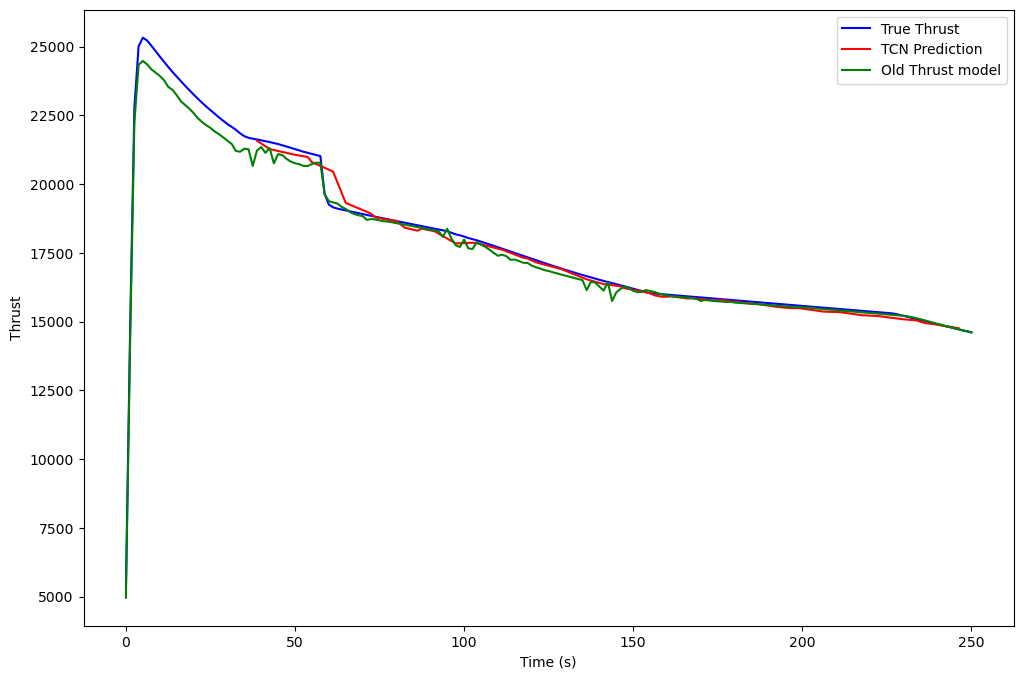

In [97]:
plt.show()

### Test on a single flight

##### 1st method : Real Thrust as input

In [171]:
def predict_thrust_from_df(df, model, scaler, device="cpu"):
    """
    df: full flight dataframe
    model: loaded ThrustTCN model
    scaler: StandardScaler reconstructed
    Returns:
        times: np.array of timestamps (airborne)
        preds: np.array of predicted thrust values
    """
    POINT_FEATURES = [
        "Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta",
        "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos",
        "Wind_dir_sin", "Total_Weight",
    ]
    
    # ---- 1) PREPARE DATAFRAME ----
    df = df.dropna(subset=POINT_FEATURES + ["Time", "Thrust"])
    df = df.sort_values("Time").reset_index(drop=True)

    # ---- 2) Find t0 ----
    ground_rows = df[df["Altitude_Above_Ground"] == 0]
    if len(ground_rows) == 0:
        raise ValueError("No ground rows in the dataframe!")
    t0 = float(ground_rows.iloc[-1]["Time"])
    max_ground_thrust = float(ground_rows["Thrust"].max())

    # ---- 3) Extract airborne rows ----
    air_df = df[(df["Altitude_Above_Ground"] > 0) & (df["Time"] > t0)].reset_index(drop=True)
    if air_df.empty:
        raise ValueError("No airborne rows found after t0.")

    times = air_df["Time"].values.astype(float)
    
    # ---- 4) Build full input sequence at once ----
    # For TCN, we need a complete sequence with dt and prev_thrust
    inputs_list = []
    prev_t = max_ground_thrust
    
    for i in range(len(times)):
        feats = air_df.loc[i, POINT_FEATURES].values.astype(float)
        dt = (times[i] - t0) if i == 0 else (times[i] - times[i-1])
        inputs_list.append(np.concatenate([feats, [dt, prev_t]]))
        # In this approach, we use true previous thrust (or model-predicted if preferred)
        prev_t = air_df.loc[i, "Thrust"] 

    full_inputs = np.vstack(inputs_list) # (T, D)

    # ---- 5) Scale and Predict ----
    x_scaled = scaler.transform(full_inputs) # Scale (T, D)
    x = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device) # (1, T, D)

    model.eval()
    with torch.no_grad():
        # TCN predicts the whole sequence in one pass
        preds = model(x).squeeze(0).cpu().numpy() # (T,)

    return times, preds

In [172]:
f_lst_test[1]

'Data\\Departures\\2024-07-26---08-27-12.csv'

In [173]:
Data_test.head()

,Vg_1,Vc_1,wind_speed_1,wind_dir_cos_1,wind_dir_sin_1,theta_1,sigma_1,delta_1,roll_1,climb_angle_1,...,theta_3,sigma_3,delta_3,roll_3,climb_angle_3,acc_max,Total_Weight,ID,Climb_CAS,Thrust_Max
0,158.374865,169.616113,10.863440,0.995330,0.066321,0.936929,1.012192,0.981059,-5.235552,10.297634,...,0.881883,0.769300,0.701831,-0.000270,7.330027,5.182957,162202.757819,Data\Departures\2024-07-28---18-45-50.csv,169.950740,25327.022950
1,136.908853,153.830988,17.043633,0.982666,-0.130336,0.944154,1.019050,0.995319,12.033464,14.115241,...,0.887821,0.774996,0.711789,0.000005,9.171222,4.857361,126134.013370,Data\Departures\2024-07-26---08-27-12.csv,153.155438,20759.240684
2,163.914620,161.804324,12.644105,0.965307,-0.172740,0.946238,0.847583,0.829673,10.293367,7.165854,...,0.889398,0.644140,0.592655,-0.000270,5.383932,4.390213,139552.401932,Data\Departures\2024-07-13---06-12-00.csv,160.615154,17939.430497
3,158.315820,166.142201,15.947592,0.997431,0.055067,0.990089,0.915337,0.937539,-1.901970,9.262010,...,0.927498,0.705610,0.677026,-0.000004,6.795367,4.308073,158505.345482,Data\Departures\2024-07-18---23-35-34.csv,166.067309,22461.892685
4,137.631540,152.003075,26.689808,0.998272,0.042644,0.965505,0.864295,0.863250,-4.401431,9.441092,...,0.905679,0.659505,0.617902,-0.008226,6.762543,4.532370,126996.746737,Data\Departures\2024-07-28---07-21-59.csv,152.900570,17878.761939


In [204]:
# For test_flight
test_flight = pd.read_csv(f_lst_test[1])
ground_rows_test = test_flight[test_flight["Altitude_Above_Ground"] == 0]
t0 = float(ground_rows_test.iloc[-1]["Time"])
air_test_flight = test_flight[(test_flight["Altitude_Above_Ground"] > 0) & (test_flight["Time"] > t0)].reset_index(drop=True)
air_test_flight.columns

Index(['Time', 'Distance', 'Altitude_Above_Ground', 'Latitude', 'Longitude',
       'Throttle', 'Thrust', 'Thrust_Corrected', 'Engine_N1', 'Engine_N2',
       'Ground_Speed', 'CAS', 'TAS', 'ROC', 'Acceleration', 'Flap_Stick',
       'theta', 'delta', 'sigma', 'Alpha', 'vpath', 'hpath', 'Roll', 'Heading',
       'CL_overall', 'CD_overall', 'Wind_Speed', 'Wind_Direction',
       'Wind_dir_sin', 'Wind_dir_cos', 'Total_Weight', 'Segment', 'Flap_0',
       'Flap_1', 'Flap_5', 'Flap_10', 'Flap_15', 'Flap_25', 'Flap_30',
       'Flap_40', 'Flap_Changing', 'Runway_Friction', 'Climb_CAS'],
      dtype='str')

In [174]:
model_thrust = keras.models.load_model(r"Models\model_thrust\model_thrust.keras")
scaler_thrust = load(r"Models\model_thrust\scaler_thrust.bin")

flight_data = air_test_flight[thrust_columns]
flight_data_scaled = pd.DataFrame(scaler_thrust.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
X_flight = flight_data_scaled[thrust_columns[:-1]]

start_time = time.time()
y_pred_scaled = model_thrust.predict(X_flight)

output = scaler_thrust.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))

y_pred_2 = output[:,-1]
end_time = time.time()
print(end_time - start_time)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 
0.23414254188537598


In [175]:
df = pd.read_csv(f_lst_test[1])
model_thrust_tcn, scaler_thrust_tcn, input_dim = load_thrust_model(path="Models/model_thrust/best_thrust_tcn.pt")
times, pred_thrust = predict_thrust_from_df(df, model_thrust_tcn, scaler_thrust_tcn)

print(times)
print(pred_thrust)

[ 25.25    26.3125  27.375   28.4375  29.625   30.6875  31.8125  33.
  34.0625  35.3125  36.375   37.5625  38.6875  39.75    40.8125  41.875
  42.9375  44.      45.0625  46.125   47.3125  48.375   49.5625  50.6875
  51.75    52.8125  53.875   55.      56.0625  57.125   58.1875  59.3125
  60.5     61.625   62.6875  63.8125  65.      66.125   67.25    68.4375
  69.625   70.6875  71.8125  73.      74.0625  75.125   76.375   77.4375
  78.5     79.5625  80.625   81.75    82.8125  83.9375  85.      86.0625
  87.125   88.1875  89.375   90.4375  91.5     92.625   93.6875  94.8125
  95.875   97.125   98.25    99.4375 100.5    101.5625 102.6875 103.75
 104.8125 105.875  106.9375 108.     109.25   110.4375 111.5    112.6875
 113.8125 114.9375 116.125  117.3125 118.375  119.4375 120.5625 121.75
 122.8125 124.0625 125.25   126.3125 127.4375 128.625  129.6875 130.75
 131.9375 133.     134.0625 135.25   136.4375 137.625  138.6875 139.875
 140.9375 142.     143.0625 144.1875 145.375  146.5    147.5625

In [176]:
len(pred_thrust)

157

In [177]:
train_ds[0]["targets"]

tensor([17493.4980, 17434.8945, 17361.4746, 17165.1621, 17101.5449, 16923.1387,
        16813.2598, 15544.6113, 15418.7988, 15394.2471, 15343.5391, 15200.6074,
        15156.6016, 15109.9707, 14977.2393, 14888.4346, 14768.4004, 14568.4756,
        14327.5615, 14262.6289, 14124.9062, 13986.1758, 13952.7412, 13751.1982,
        13654.9727, 13497.2979, 13378.9736, 13347.2285, 13148.7090, 13067.3633,
        12992.8789, 12971.1650, 12896.1250, 12869.9785, 12737.5215, 12649.3311,
        12625.5791, 12617.5762, 12609.7549, 12593.5273, 12577.7607, 12528.9902,
        12520.0557, 12471.7949, 12447.8193, 12422.8770, 12374.1084, 12326.2285,
        12293.8799, 12253.8232, 12206.2041, 12173.2637, 12157.2783, 12133.1377,
        12084.7539, 12069.6475])

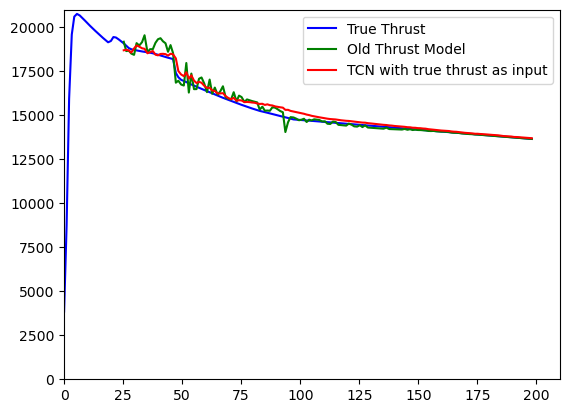

In [219]:
plt.plot(df["Time"],df["Thrust"], "b", label = "True Thrust")
plt.plot(air_test_flight["Time"], y_pred_2, "g", label = "Old Thrust Model")
plt.plot(times, pred_thrust, "r", label = "TCN with true thrust as input")
plt.ylim([0,21000])
plt.xlim([0, 210])
plt.legend()
plt.show()

##### 2nd method (predicted thrust max as inputs)

In [180]:
from tensorflow.keras.models import load_model
from joblib import load
model_thrust_max = load_model("Models/model_thrust/model_thrust_max.keras")
scaler_thrust_max = load("Models/model_thrust/scaler_thrust_max.bin")

In [205]:
def predict_thrust_from_tmm(df, model, scaler, device="cpu"):
    #tmm = thrust max model
    """
    df: full flight dataframe
    model: loaded ThrustTCN model
    scaler: StandardScaler reconstructed
    Returns:
        times: np.array of timestamps (airborne)
        preds: np.array of predicted thrust values
    """
    POINT_FEATURES = [
        "Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta",
        "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos",
        "Wind_dir_sin", "Total_Weight"
    ]
    
    # ---- 1) PREPARE DATAFRAME ----
    df = df.dropna(subset=POINT_FEATURES + ["Time", "Thrust"])
    df = df.sort_values("Time").reset_index(drop=True)

    # ---- 2) Find t0 ----
    ground_rows = df[df["Altitude_Above_Ground"] == 0]
    if len(ground_rows) == 0:
        raise ValueError("No ground rows in the dataframe!")
    t0 = float(ground_rows.iloc[-1]["Time"])
    max_ground_thrust = float(ground_rows["Thrust"].max())
    #----------2.5) Thrust max predictions ------------
    

    # ---- 3) Extract airborne rows ----
    air_df = df[(df["Altitude_Above_Ground"] > 0) & (df["Time"] > t0)].reset_index(drop=True)
    if air_df.empty:
        raise ValueError("No airborne rows found after t0.")

    times = air_df["Time"].values.astype(float)

    #=================================================
    flight_data_2 = air_df[thrust_columns]
    flight_data_2_scaled = pd.DataFrame(scaler_thrust_max.transform(flight_data_2.values), index=flight_data_2.index, columns=flight_data_2.columns)
    X_flight_2 = flight_data_2_scaled[thrust_columns[:-1]]

    start_time = time.time()
    y_pred_scaled_2 = model_thrust_max.predict(X_flight_2)

    output_2 = scaler_thrust_max.inverse_transform(np.concatenate((X_flight_2.values, y_pred_scaled_2.reshape(len(y_pred_scaled_2),1)), axis=1))

    y_pred_2_ = output_2[:,-1]
    end_time = time.time()
    print(end_time - start_time)
    flight_data_2["y_pred"] = y_pred_2_
    #==============================================================
    
    # ---- 4) Build full input sequence at once ----
    # For TCN, we need a complete sequence with dt and prev_thrust
    inputs_list = []
    prev_t = max_ground_thrust
    
    for i in range(len(times)):
        feats = air_df.loc[i, POINT_FEATURES].values.astype(float)
        dt = (times[i] - t0) if i == 0 else (times[i] - times[i-1])
        inputs_list.append(np.concatenate([feats, [dt, prev_t]]))
        # In this approach, we use true previous thrust (or model-predicted if preferred)
        prev_t = air_df.loc[i, "Thrust"] 

    full_inputs = np.vstack(inputs_list) # (T, D)

    # ---- 5) Scale and Predict ----
    x_scaled = scaler.transform(full_inputs) # Scale (T, D)
    x = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device) # (1, T, D)

    model.eval()
    with torch.no_grad():
        # TCN predicts the whole sequence in one pass
        preds = model(x).squeeze(0).cpu().numpy() # (T,)

    return times, preds

In [206]:
df = pd.read_csv(f_lst_test[1])
model_thrust_tcn, scaler_thrust_tcn, input_dim = load_thrust_model(path="Models/model_thrust/best_thrust_tcn.pt")
times, pred_thrust = predict_thrust_from_tmm(df, model_thrust_tcn, scaler_thrust_tcn)

print(times)
print(pred_thrust)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
0.12230157852172852
[ 25.25    26.3125  27.375   28.4375  29.625   30.6875  31.8125  33.
  34.0625  35.3125  36.375   37.5625  38.6875  39.75    40.8125  41.875
  42.9375  44.      45.0625  46.125   47.3125  48.375   49.5625  50.6875
  51.75    52.8125  53.875   55.      56.0625  57.125   58.1875  59.3125
  60.5     61.625   62.6875  63.8125  65.      66.125   67.25    68.4375
  69.625   70.6875  71.8125  73.      74.0625  75.125   76.375   77.4375
  78.5     79.5625  80.625   81.75    82.8125  83.9375  85.      86.0625
  87.125   88.1875  89.375   90.4375  91.5     92.625   93.6875  94.8125
  95.875   97.125   98.25    99.4375 100.5    101.5625 102.6875 103.75
 104.8125 105.875  106.9375 108.     109.25   110.4375 111.5    112.6875
 113.8125 114.9375 116.125  117.3125 118.375  119.4375 120.5625 121.75
 122.8125 124.0625 125.25   126.3125 127.4375 128.625  129.6875 130.75
 131.9375 133.     134.0625 135.25   136.4375 137.625  138.6875 139.875
 140.

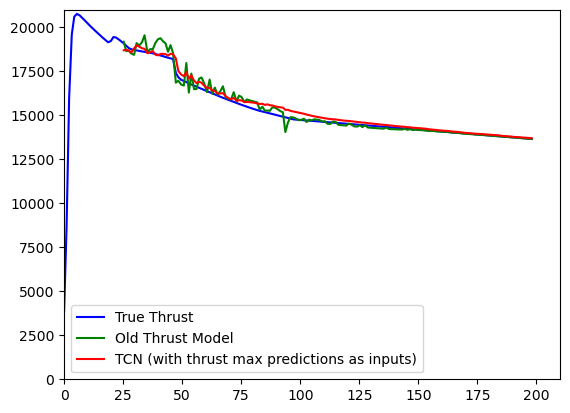

In [220]:
plt.plot(df["Time"],df["Thrust"], "b", label = "True Thrust")
plt.plot(air_test_flight["Time"], y_pred_2, "g", label = "Old Thrust Model")
plt.plot(times, pred_thrust, "r", label = "TCN (with thrust max predictions as inputs)")
plt.ylim([0,21000])
plt.xlim([0, 210])
plt.legend()
plt.show()

# Test on ADSB Data

In [130]:
import os
from pathlib import Path
base_dir = Path(os.getcwd())
flight_list_path = base_dir / "flight_list.csv"
flight_list = pd.read_csv(flight_list_path, index_col="flight_id")
airports_file_path = base_dir / "airports.csv"
airports = pd.read_csv(airports_file_path, encoding="ISO-8859-1")


In [131]:
flight_id = 250846044
flight_list.loc[flight_id]

date                                          16/04/2022
callsign                9c529066bdda557322349b04efee3ce7
adep                                                LYBE
name_adep                                       Belgrade
country_code_adep                                     RS
ades                                                LTFM
name_ades                                   iGA Istanbul
country_code_ades                                     TR
actual_offblock_time                2022-04-16T13:55:00Z
arrival_time                        2022-04-16T15:14:00Z
aircraft_type                                       B738
wtc                                                    M
airline                 6351ec1b849adacc0cbb3b1313d8d39b
flight_duration                                       69
taxiout_time                                          10
flown_distance                                       460
tow                                              59816.0
Name: 250846044, dtype: object

In [132]:
df_adsb = pd.read_parquet(r"C:\Users\LEGION-local user\Desktop\Aircraft Types\B738\Raw Data\2022-04-16_B738.parquet")

In [133]:
flight_data = df_adsb[df_adsb["flight_id"]==flight_id]
# 1. Check if Latitude equals the PREVIOUS row's Latitude
lat_same = flight_data['latitude'] == flight_data['latitude'].shift()

# 2. Check if Longitude equals the PREVIOUS row's Longitude
lon_same = flight_data['longitude'] == flight_data['longitude'].shift()

# 3. Filter: Keep row if NOT (lat_same AND lon_same)
#    This removes the row only if BOTH stayed the same
flight_data = flight_data[~(lat_same & lon_same)]
flight_data.reset_index(inplace=True, drop=True)
flight_data

,flight_id,timestamp,latitude,longitude,altitude,groundspeed,track,vertical_rate,icao24,u_component_of_wind,v_component_of_wind,temperature,specific_humidity,aircraft_type
0,250846044,2022-04-16 14:05:11+00:00,44.822754,20.299530,200.0,103.0,122.300416,64.0,250846044,3.280679,-5.391805,288.367287,0.004566,B738
1,250846044,2022-04-16 14:05:13+00:00,44.822217,20.300725,200.0,112.0,122.550003,64.0,250846044,3.281522,-5.386707,288.367616,0.004566,B738
2,250846044,2022-04-16 14:05:15+00:00,44.821565,20.302131,200.0,123.0,122.399840,64.0,250846044,3.282604,-5.380557,288.368096,0.004566,B738
3,250846044,2022-04-16 14:05:16+00:00,44.821100,20.303203,200.0,128.0,122.195734,64.0,250846044,3.283484,-5.375834,288.368496,0.004566,B738
4,250846044,2022-04-16 14:05:18+00:00,44.820602,20.304369,200.0,135.0,122.275644,64.0,250846044,3.284218,-5.370913,288.368753,0.004567,B738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3420,250846044,2022-04-16 15:13:24+00:00,41.211579,28.757650,1325.0,145.0,359.209763,-640.0,250846044,-2.575685,-0.900732,290.772510,0.004856,B738
3421,250846044,2022-04-16 15:13:26+00:00,41.212875,28.757629,1300.0,145.0,359.209763,-704.0,250846044,-2.574876,-0.878812,290.800310,0.004924,B738
3422,250846044,2022-04-16 15:13:30+00:00,41.216001,28.757588,1250.0,145.0,359.209763,-704.0,250846044,-2.573455,-0.832746,290.855883,0.005062,B738
3423,250846044,2022-04-16 15:13:33+00:00,41.218096,28.757525,1200.0,145.0,359.209763,-768.0,250846044,-2.574200,-0.789577,290.911565,0.005199,B738


In [134]:
df_adsb_test = pd.read_csv("real_flight_test.csv")
df_adsb_test

,flight_id,timestamp,latitude,longitude,Altitude_Above_Ground,Ground_Speed,track,vertical_rate,icao24,u_component_of_wind,...,Roll,Climb_Angle,theta,delta,sigma,TAS,CAS,Wind_dir_cos,Wind_dir_sin,vpath
0,250846044,2022-04-16 14:05:11+00:00,44.822754,20.299530,0.0,103.0,122.300416,64.0,250846044,3.280679,...,0.475501,0.000000,0.969814,0.992988,0.989554,109.310578,108.738124,-0.895860,-0.444336,NaN
1,250846044,2022-04-16 14:05:13+00:00,44.822217,20.300725,0.0,112.0,122.550003,64.0,250846044,3.281522,...,0.475501,0.000000,0.969814,0.992988,0.989554,118.306224,117.686659,-0.898022,-0.439950,0.000000
2,250846044,2022-04-16 14:05:15+00:00,44.821565,20.302131,0.0,123.0,122.399840,64.0,250846044,3.282604,...,-0.357525,0.000000,0.969814,0.992988,0.989554,129.301910,128.624762,-0.897155,-0.441715,0.000000
3,250846044,2022-04-16 14:05:16+00:00,44.821100,20.303203,0.0,128.0,122.195734,64.0,250846044,3.283484,...,-0.874846,0.000000,0.969814,0.992988,0.989554,134.298719,133.595403,-0.895803,-0.444452,0.000000
4,250846044,2022-04-16 14:05:18+00:00,44.820602,20.304369,0.0,135.0,122.275644,64.0,250846044,3.284218,...,0.449727,0.000000,0.969814,0.992988,0.989554,141.294826,140.554871,-0.896646,-0.442747,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,250846044,2022-04-16 14:09:23+00:00,44.687309,20.604590,9800.0,266.0,119.451470,2880.0,250846044,10.449424,...,0.000000,6.051499,0.904693,0.689097,0.736144,271.581926,233.014165,-0.887900,0.460037,0.104218
249,250846044,2022-04-16 14:09:24+00:00,44.686331,20.607002,9875.0,267.0,119.638384,2816.0,250846044,10.540690,...,2.409564,5.730039,0.904195,0.687104,0.734420,272.573083,233.590500,-0.881695,0.471820,0.104218
250,250846044,2022-04-16 14:09:25+00:00,44.685974,20.607867,9900.0,267.0,119.638384,2688.0,250846044,10.571168,...,0.000000,5.006230,0.904029,0.686441,0.733846,272.566212,233.493296,-0.880128,0.474737,0.104197
251,250846044,2022-04-16 14:09:26+00:00,44.685150,20.610025,9950.0,267.0,119.638384,2560.0,250846044,10.633060,...,-0.000000,5.389532,0.903696,0.685116,0.732699,272.536464,233.285259,-0.876954,0.480574,0.104028


In [135]:
df_adsb_test.columns

Index(['flight_id', 'timestamp', 'latitude', 'longitude',
       'Altitude_Above_Ground', 'Ground_Speed', 'track', 'vertical_rate',
       'icao24', 'u_component_of_wind', 'v_component_of_wind', 'temperature',
       'specific_humidity', 'aircraft_type', 'Time', 'Wind_Speed',
       'wind_direction', 'Distance', 'Acceleration', 'Roll', 'Climb_Angle',
       'theta', 'delta', 'sigma', 'TAS', 'CAS', 'Wind_dir_cos', 'Wind_dir_sin',
       'vpath'],
      dtype='str')

In [137]:
vpath = df_adsb_test["Altitude_Above_Ground"]/df_adsb_test["Distance"]
vpath[0] = 0
vpath

0      0.000000
1      0.000000
2      0.000000
3      0.000000
4      0.000000
         ...   
248    0.104218
249    0.104218
250    0.104197
251    0.104028
252    0.104056
Length: 253, dtype: float64

In [138]:
df_adsb_test['vpath'] = vpath

In [139]:
df_adsb_test = df_adsb_test.rename(columns={"altitude": "Altitude_Above_Ground", "groundspeed" : "Ground_Speed", "Roll_Angle" : "Roll",
                                            "wind_speed" : "Wind_Speed", "wind_dir_cos" : "Wind_dir_cos", 
                                           "wind_dir_sin" : "Wind_dir_sin"})

In [140]:
df_adsb_test.columns

Index(['flight_id', 'timestamp', 'latitude', 'longitude',
       'Altitude_Above_Ground', 'Ground_Speed', 'track', 'vertical_rate',
       'icao24', 'u_component_of_wind', 'v_component_of_wind', 'temperature',
       'specific_humidity', 'aircraft_type', 'Time', 'Wind_Speed',
       'wind_direction', 'Distance', 'Acceleration', 'Roll', 'Climb_Angle',
       'theta', 'delta', 'sigma', 'TAS', 'CAS', 'Wind_dir_cos', 'Wind_dir_sin',
       'vpath'],
      dtype='str')

In [141]:
df_adsb_test["timestamp"] = pd.to_datetime(df_adsb_test["timestamp"])
df_adsb_test["Time"] = (df_adsb_test["timestamp"] - df_adsb_test["timestamp"].iloc[0]).dt.total_seconds()
df_adsb_test["Time"]

0        0.0
1        2.0
2        4.0
3        5.0
4        7.0
       ...  
248    252.0
249    253.0
250    254.0
251    255.0
252    256.0
Name: Time, Length: 253, dtype: float64

#### Weights prediction

In [142]:
from tensorflow.keras.models import load_model
from joblib import load 
model = load_model("Models/model_weight/model_weight.keras")
scaler = load ("Models/model_weight/scaler_weight.bin")
df_adsb_test["Total_Weight"] = 0

In [143]:
all_names_new = ["Ground_Speed", "CAS", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "Climb_Angle", "Total_Weight"]
x_names_new = all_names_new[:-1]

df_adsb_test_scaled = pd.DataFrame(scaler.transform(df_adsb_test[all_names_new].values), index=df_adsb_test.index, columns=all_names_new)
X = df_adsb_test_scaled[x_names_new]

y_pred_scaled = model.predict(X)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [144]:
output_new = scaler.inverse_transform(np.concatenate((X, y_pred_scaled), axis=1))
estimated_weight = np.mean(output_new[:,-1])
print(f"Estimated Weight = {estimated_weight}") 

Estimated Weight = 167011.29646276037


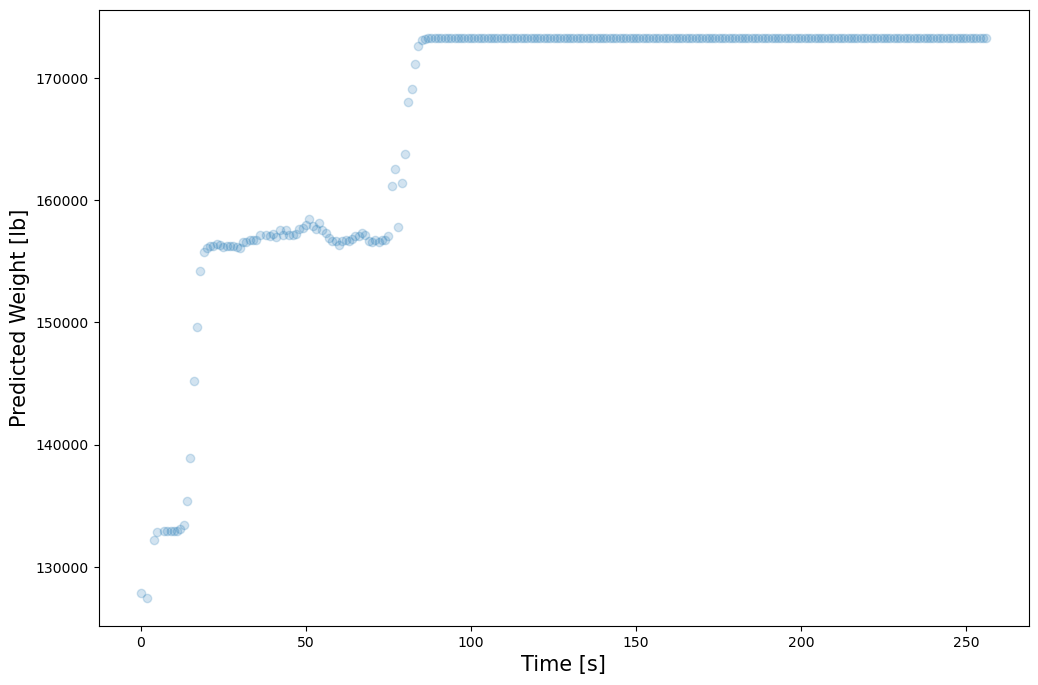

Estimated Weight = 167011.29646276037


In [145]:
plt.figure(figsize=(12,8))
plt.scatter(df_adsb_test["Time"], output_new[:,-1], alpha=0.2)
plt.ylabel("Predicted Weight [lb]", fontsize=15)
plt.xlabel("Time [s]", fontsize=15)
#plt.plot([120000, 175000], [120000, 175000], "r")
plt.show()
estimated_weight = np.mean(output_new[:,-1])
print(f"Estimated Weight = {estimated_weight}") 

In [128]:
print(f"Predictions = {output_new[:,-1]}")

Predictions = [127834.03458902 127470.48245106 132222.28372715 132832.29306651
 132898.87251429 132898.88258048 132902.60203709 132908.85985088
 132932.39459936 133062.37593478 133393.9360483  135360.85751784
 138911.28269613 145202.62507113 149652.49039701 154233.50914013
 155785.49267704 156096.25604533 156297.16709961 156292.72707168
 156428.52079205 156364.3471633  156166.40898999 156254.26164926
 156240.27971357 156279.09745259 156209.11479428 156067.2545177
 156618.46137867 156566.78660052 156746.61905629 156788.06742588
 156772.96898213 157164.21991517 157187.98115289 157086.01234209
 157220.03525215 157007.39373299 157529.71986059 157192.57636789
 157535.46765417 157162.83078117 157145.73503787 157248.78596392
 157690.68744045 157770.7849404  157979.25150792 158468.02451304
 157927.7721816  157652.62298786 158102.83326407 157568.54514925
 157354.68058819 156937.66776249 156675.67088275 156652.73758902
 156334.65358522 156675.82019788 156789.58238723 156647.46542285
 156858.9107

In [51]:
df_adsb_test.to_csv("real_flight_test.csv", index=False)

In [149]:
dataframe = pd.read_csv(f_lst_test[1])
model_thrust_tcn, scaler_thrust_tcn, input_dim = load_thrust_model(path="Models/model_thrust/best_thrust_tcn.pt")
times, pred_thrust = predict_thrust_from_df(df, model_thrust_tcn, scaler_thrust_tcn)

print(times)
print(pred_thrust)

[ 37.96875  39.03125  40.09375  41.15625  42.1875   43.3125   44.34375
  45.375    46.40625  47.46875  48.6875   49.84375  50.9375   52.
  53.15625  54.25     55.3125   56.40625  57.4375   58.46875  59.625
  60.78125  61.90625  62.9375   64.0625   65.15625  66.21875  67.28125
  68.4375   69.46875  70.5      71.53125  72.65625  73.71875  74.75
  75.8125   76.875    77.9375   78.96875  80.03125  81.09375  82.15625
  83.3125   84.34375  85.40625  86.46875  87.53125  88.625    89.6875
  90.75     91.78125  92.84375  93.90625  94.96875  96.125    97.21875
  98.28125  99.34375 100.4375  101.5     102.8125  103.84375 105.
 106.125   107.21875 108.28125 109.375   110.4375  111.5     112.5625
 113.59375 114.65625 115.8125  116.90625 118.03125 119.09375 120.125
 121.15625 122.1875  123.25    124.3125  125.46875 126.53125 127.5625
 128.59375 129.625   130.78125 131.84375 133.      134.0625  135.125
 136.21875 137.28125 138.3125  139.375   140.5     141.53125 142.65625
 143.71875 144.75    145.812